# Feature Engineering

Ce notebook applique le feature engineering aux données après traitement des valeurs aberrantes et sauvegarde les résultats.

**Prérequis** : Exécuter `exploration_base_donnees.ipynb` (sections 12-15) pour obtenir les données après traitement des outliers.

In [1]:
# Imports
# Au début du notebook
import time
start_time = time.time()

import sys
from pathlib import Path

# Ajouter le dossier parent au path pour les imports
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import logging
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from src.feature_engineering import FeatureEngineer

logging.basicConfig(level=logging.INFO)

In [2]:
# Charger les données finales propres
train_df = pd.read_csv("../data/processed/train_final.csv", keep_default_na=False, na_filter=False)
test_df = pd.read_csv("../data/processed/test_final.csv", keep_default_na=False, na_filter=False)

print("=" * 60)
print("CHARGEMENT DES DONNÉES (JEUX FINAUX PROPRES)")
print("=" * 60)
print(f"Données chargées: Train {train_df.shape}, Test {test_df.shape}")

# Vérification immédiate des NA après import
print("\nVérification NA (brut import):")
print("Train - total NA:", train_df.isna().sum().sum())
print("Test  - total NA:", test_df.isna().sum().sum())
print("Top 5 colonnes avec NA (train):")
print(train_df.isna().sum().sort_values(ascending=False).head())
print("Top 5 colonnes avec NA (test):")
print(test_df.isna().sum().sort_values(ascending=False).head())

CHARGEMENT DES DONNÉES (JEUX FINAUX PROPRES)
Données chargées: Train (1460, 82), Test (1459, 80)

Vérification NA (brut import):
Train - total NA: 0
Test  - total NA: 0
Top 5 colonnes avec NA (train):
identifiant                0
type_de_logement           0
zonage_classification      0
facade_en_pieds            0
superficie_du_lot_pieds    0
dtype: int64
Top 5 colonnes avec NA (test):
identifiant                0
type_de_logement           0
zonage_classification      0
facade_en_pieds            0
superficie_du_lot_pieds    0
dtype: int64


In [3]:
# =========================
# STEP 1 — Age + Surface FE
# =========================

def add_basic_features(df):
    df = df.copy()

    # Mise au format numérique des colonnes utilisées (certaines arrivent en chaînes "NA")
    numeric_needed = [
        "annee_de_vente", "annee_de_construction", "annee_de_renovation", "annee_de_construction_du_garage",
        "total_surface_sous_sol", "surface_du_premier_etage", "surface_du_deuxieme_etage",
        "surface_du_porche_ouvert", "porche_ferme", "porche_trois_saisons", "porche_screen",
        "salles_de_bain_completes", "demi_salles_de_bain", "salles_de_bain_completes_sous_sol", "demi_salles_de_bain_sous_sol"
    ]
    for col in numeric_needed:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 1) Ages (année de vente - année de construction/rénovation)
    df["age_maison"] = df["annee_de_vente"] - df["annee_de_construction"]
    df["age_renovation"] = df["annee_de_vente"] - df["annee_de_renovation"]

    # Age du garage (si colonne existe)
    if "annee_de_construction_du_garage" in df.columns:
        # si pas de garage, l'année peut être 0 ou NaN -> on laisse, puis on sécurise
        df["age_garage"] = df["annee_de_vente"] - df["annee_de_construction_du_garage"]
    else:
        df["age_garage"] = 0

    # Sécurisation: pas d'âge négatif
    for col in ["age_maison", "age_renovation", "age_garage"]:
        if col in df.columns:
            df[col] = df[col].clip(lower=0)

    # 2) Surfaces globales
    df["surface_totale"] = (
        df.get("total_surface_sous_sol", 0)
        + df.get("surface_du_premier_etage", 0)
        + df.get("surface_du_deuxieme_etage", 0)
    )

    # 3) Porches
    df["surface_totale_porches"] = (
        df.get("surface_du_porche_ouvert", 0)
        + df.get("porche_ferme", 0)
        + df.get("porche_trois_saisons", 0)
        + df.get("porche_screen", 0)
    )

    # 4) TotalBath (pondéré)
    df["total_salles_bain"] = (
        df.get("salles_de_bain_completes", 0)
        + 0.5 * df.get("demi_salles_de_bain", 0)
        + df.get("salles_de_bain_completes_sous_sol", 0)
        + 0.5 * df.get("demi_salles_de_bain_sous_sol", 0)
    )

    return df


# Application sur train & test
train_df_fe = add_basic_features(train_df)
test_df_fe  = add_basic_features(test_df)

print("Shapes:")
print("Train:", train_df.shape, "->", train_df_fe.shape)
print("Test :", test_df.shape, "->", test_df_fe.shape)

# Vérifs rapides (min/max + valeurs négatives)
check_cols = [
    "age_maison", "age_renovation", "age_garage",
    "surface_totale", "surface_totale_porches", "total_salles_bain"
]
print("\nQuick stats (train):")
display(train_df_fe[check_cols].describe().T)

print("\nNégatifs? (train)")
display((train_df_fe[check_cols] < 0).sum())


Shapes:
Train: (1460, 82) -> (1460, 88)
Test : (1459, 80) -> (1459, 86)

Quick stats (train):


,count,mean,std,min,25%,50%,75%,max
age_maison,1460.0,36.547945,30.250152,0.0,8.0,35.0,54.0,136.00
age_renovation,1460.0,22.950685,20.639875,0.0,4.0,14.0,41.0,60.00
age_garage,1379.0,29.306019,24.726881,0.0,6.0,28.0,47.0,107.00
surface_totale,1460.0,2561.450685,786.724834,334.0,2009.5,2474.0,3004.0,7797.05
surface_totale_porches,1460.0,87.084932,105.190364,0.0,0.0,48.0,136.0,1027.00
total_salles_bain,1460.0,2.210616,0.785399,1.0,2.0,2.0,2.5,6.00



Négatifs? (train)


age_maison                0
age_renovation            0
age_garage                0
surface_totale            0
surface_totale_porches    0
total_salles_bain         0
dtype: int64

On note un souci avec la variable GarageAge qui a une valeur maximale de 2010 c equi est impossible peut être car y a des maisons ou y a pas de garage et donc 2010-0=2010.

In [4]:
def fix_garage_age(df):
    df = df.copy()

    # Colonnes critiques converties en numérique (au cas où elles arrivent en chaînes)
    for col in ["annee_de_vente", "annee_de_construction_du_garage"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 1) indicateur garage
    df["presence_garage"] = (df["annee_de_construction_du_garage"].fillna(0) > 0).astype(int)

    # 2) Age du garage (0 si pas de garage)
    df["age_garage"] = np.where(
        df["presence_garage"] == 1,
        df["annee_de_vente"] - df["annee_de_construction_du_garage"],
        0
    )

    # 3) sécurité
    df["age_garage"] = df["age_garage"].fillna(0).clip(lower=0)

    return df


train_df_fe = fix_garage_age(train_df_fe)
test_df_fe  = fix_garage_age(test_df_fe)

display(train_df_fe[["annee_de_construction_du_garage", "presence_garage", "age_garage"]].describe())


,annee_de_construction_du_garage,presence_garage,age_garage
count,1379.000000,1460.000000,1460.000000
mean,1978.506164,0.944521,27.680137
std,24.689725,0.228992,24.950144
min,1900.000000,0.000000,0.000000
25%,1961.000000,1.000000,4.000000
50%,1980.000000,1.000000,23.500000
75%,2002.000000,1.000000,46.000000
max,2010.000000,1.000000,107.000000


In [5]:
ordinal_cols = [
    "forme_du_lot", "inclinaison_du_terrain",
    "qualite_exterieure", "etat_exterieur",
    "qualite_du_sous_sol", "etat_general_du_sous_sol", "exposition_du_sous_sol", "type_de_finition_sous_sol_1", "type_de_finition_sous_sol_2",
    "qualite_du_chauffage", "qualite_de_la_cuisine", "fonctionnalite_globale", "qualite_de_la_cheminee",
    "finition_interieure_du_garage", "qualite_du_garage", "condition_du_garage",
    "qualite_de_la_piscine", "cloture"
]

def afficher_modalites(df, cols, dropna=False, tri=True):
    # Garde seulement les colonnes qui existent dans df
    cols_existantes = [c for c in cols if c in df.columns]
    cols_absentes = [c for c in cols if c not in df.columns]
    if cols_absentes:
        print("⚠️ Colonnes absentes du DataFrame :", cols_absentes)

    for c in cols_existantes:
        valeurs = df[c].unique() if not dropna else df[c].dropna().unique()
        valeurs = list(valeurs)

        if tri:
            # Tri “propre” même s'il y a des NaN / types mixtes
            valeurs = sorted(valeurs, key=lambda x: "" if pd.isna(x) else str(x))

        print(f"\n--- {c} ---")
        print(f"Nombre de modalités : {len(valeurs)}")
        print(valeurs)

# Exemple : sur train_df
afficher_modalites(train_df, ordinal_cols, dropna=False, tri=True)



--- forme_du_lot ---
Nombre de modalités : 4
['Irrégulier', 'Légèrement irrégulier', 'Modérément irrégulier', 'Régulier']

--- inclinaison_du_terrain ---
Nombre de modalités : 3
['Pente douce', 'Pente modérée', 'Pente sévère']

--- qualite_exterieure ---
Nombre de modalités : 4
['Bon', 'Excellent', 'Moyen', 'Médiocre']

--- etat_exterieur ---
Nombre de modalités : 5
['Bon', 'Excellent', 'Mauvais', 'Moyen', 'Médiocre']

--- qualite_du_sous_sol ---
Nombre de modalités : 5
['Bon', 'Excellent', 'Moyen', 'Médiocre', 'NA']

--- etat_general_du_sous_sol ---
Nombre de modalités : 5
['Bon', 'Mauvais', 'Moyen', 'Médiocre', 'NA']

--- exposition_du_sous_sol ---
Nombre de modalités : 5
['Aucune exposition', 'Bonne exposition', 'Exposition au niveau moyen', 'Exposition moyenne', 'NA']

--- type_de_finition_sous_sol_1 ---
Nombre de modalités : 7
['Fini - Excellent', 'Fini - Moyenne', 'Fini - Qualité inférieure', 'Fini - Salle de jeux', 'NA', 'Non fini', 'Partiellement fini']

--- type_de_finition_s

In [6]:
afficher_modalites(test_df, ordinal_cols, dropna=False, tri=True)



--- forme_du_lot ---
Nombre de modalités : 4
['Irrégulier', 'Légèrement irrégulier', 'Modérément irrégulier', 'Régulier']

--- inclinaison_du_terrain ---
Nombre de modalités : 3
['Pente douce', 'Pente modérée', 'Pente sévère']

--- qualite_exterieure ---
Nombre de modalités : 4
['Bon', 'Excellent', 'Moyen', 'Médiocre']

--- etat_exterieur ---
Nombre de modalités : 5
['Bon', 'Excellent', 'Mauvais', 'Moyen', 'Médiocre']

--- qualite_du_sous_sol ---
Nombre de modalités : 5
['Bon', 'Excellent', 'Moyen', 'Médiocre', 'NA']

--- etat_general_du_sous_sol ---
Nombre de modalités : 5
['Bon', 'Mauvais', 'Moyen', 'Médiocre', 'NA']

--- exposition_du_sous_sol ---
Nombre de modalités : 5
['Aucune exposition', 'Bonne exposition', 'Exposition au niveau moyen', 'Exposition moyenne', 'NA']

--- type_de_finition_sous_sol_1 ---
Nombre de modalités : 7
['Fini - Excellent', 'Fini - Moyenne', 'Fini - Qualité inférieure', 'Fini - Salle de jeux', 'NA', 'Non fini', 'Partiellement fini']

--- type_de_finition_s

In [7]:
# =========================================================
# 1) LISTES DE COLONNES (à adapter si besoin à ton dataset)
# =========================================================

ordinal_cols = [
    "forme_du_lot", "inclinaison_du_terrain",
    "qualite_exterieure", "etat_exterieur",
    "qualite_du_sous_sol", "etat_general_du_sous_sol", "exposition_du_sous_sol", "type_de_finition_sous_sol_1", "type_de_finition_sous_sol_2",
    "qualite_du_chauffage", "qualite_de_la_cuisine", "fonctionnalite_globale", "qualite_de_la_cheminee",
    "finition_interieure_du_garage", "qualite_du_garage", "condition_du_garage",
    "qualite_de_la_piscine", "cloture"
]

# Nominales (catégorielles NON ordonnées)
nominal_cols = [
    "type_de_logement", "zonage_classification", "type_de_route", "topographie_du_terrain", "services_publics_disponibles",
    "configuration_du_lot", "quartier", "proximite_1ere_condition", "proximite_2e_condition",
    "type_de_batiment", "style_de_maison", "style_de_toit", "materiau_du_toit",
    "revetement_exterieur_1", "revetement_exterieur_2", "type_de_fondation", "type_de_chauffage",
    "climatisation_centrale", "systeme_electrique",
    # tu peux ajouter ici: allee_pavee, type_de_garage, type_de_vente, condition_de_la_vente, etc.
]

# Numériques = tout le reste (hors target)
# -> tu peux soit les lister à la main, soit les détecter automatiquement
def infer_numeric_cols(df, target_col=None, ordinal_cols=None, nominal_cols=None):
    exclude = set()
    if target_col is not None:
        exclude.add(target_col)
    if ordinal_cols is not None:
        exclude |= set(ordinal_cols)
    if nominal_cols is not None:
        exclude |= set(nominal_cols)

    # on garde uniquement les colonnes restantes
    remaining = [c for c in df.columns if c not in exclude]

    # parmi elles, on ne garde que celles qui sont numériques
    numeric = [c for c in remaining if pd.api.types.is_numeric_dtype(df[c])]
    return numeric


# =========================================================
# 2) ORDRES DES CATEGORIES ORDINALES (avec "None" en plus bas)
#    IMPORTANT : l'ordre doit correspondre EXACTEMENT à ordinal_cols
# =========================================================

# Ordre commun qualité/condition (inclut cas d'absence)
qual_order = [
    "None", "Non applicable", "Pas de cheminée", "Pas de piscine", "Pas de sous-sol", "Pas de garage",
    "Mauvais - Poêle de type Ben Franklin", "Médiocre - Préfabriquée au sous-sol", "Moyen - Préfabriquée ou en maçonnerie au sous-sol",
    "Bon - Cheminée en maçonnerie au rez-de-chaussée", "Excellent - Cheminée en maçonnerie exceptionnelle",
    "Mauvais", "Médiocre", "Moyen", "Bon", "Excellent"
]

# forme_du_lot (d'après la doc Ames)
lotshape_order = ["None", "Irrégulier", "Modérément irrégulier", "Légèrement irrégulier", "Régulier"]

# inclinaison_du_terrain
landslope_order = ["None", "Pente douce", "Pente modérée", "Pente sévère"]

# exposition_du_sous_sol (ajout du cas Pas de sous-sol)
bsmtexpo_order = ["None", "Pas de sous-sol", "Aucune exposition", "Exposition moyenne", "Exposition au niveau moyen", "Bonne exposition"]

# type_de_finition_sous_sol (1/2) — inclut codes bruts et labels traduits
bsmtfin_order = [
    "None", "Pas de sous-sol", "Unf", "Non fini", "LwQ", "Fini - Qualité inférieure", "Rec", "Fini - Salle de jeux",
    "BLQ", "Partiellement fini", "ALQ", "GLQ", "Fini - Moyenne", "Fini - Excellent", "NA"
]

# fonctionnalite_globale (valeurs d'origine conservées)
functional_order = ["None", "Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"]

# finition_interieure_du_garage
garagefinish_order = ["None", "Pas de garage", "Non aménagé", "Partiellement aménagé", "Aménagé"]

# cloture
fence_order = ["None", "Pas de clôture", "Qualité minimale en bois/fil", "Bonne qualité en bois", "Intimité minimale", "Bonne intimité"]

# Les catégories ordinales dans le même ordre que ordinal_cols
ordinal_categories = [
    lotshape_order,          # forme_du_lot
    landslope_order,         # inclinaison_du_terrain
    qual_order,              # qualite_exterieure
    qual_order,              # etat_exterieur
    qual_order,              # qualite_du_sous_sol
    qual_order,              # etat_general_du_sous_sol
    bsmtexpo_order,          # exposition_du_sous_sol
    bsmtfin_order,           # type_de_finition_sous_sol_1
    bsmtfin_order,           # type_de_finition_sous_sol_2
    qual_order,              # qualite_du_chauffage
    qual_order,              # qualite_de_la_cuisine
    functional_order,        # fonctionnalite_globale
    qual_order,              # qualite_de_la_cheminee
    garagefinish_order,      # finition_interieure_du_garage
    qual_order,              # qualite_du_garage
    qual_order,              # condition_du_garage
    qual_order,              # qualite_de_la_piscine
    fence_order              # cloture
]

# =========================================================
# 3) PIPELINES
# =========================================================

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    # On force "None" pour toutes les valeurs manquantes
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    # handle_unknown au cas où une modalité inattendue apparaît
    ("encoder", OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown="use_encoded_value",
                               unknown_value=-1))
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# =========================================================
# 4) PREPROCESSOR FINAL (ColumnTransformer)
# =========================================================

def build_preprocessor(train_df, target_col=None):
    num_cols = infer_numeric_cols(
        train_df, target_col=target_col,
        ordinal_cols=ordinal_cols, nominal_cols=nominal_cols
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, num_cols),
            ("ord", ordinal_pipeline, ordinal_cols),
            ("nom", nominal_pipeline, nominal_cols),
        ],
        remainder="drop"  # on drop le reste
    )
    return preprocessor, num_cols





In [8]:
# À la fin du notebook
end_time = time.time()
duration = end_time - start_time
print(f"Durée totale d'exécution : {duration:.2f} secondes")

Durée totale d'exécution : 13.05 secondes


Vérification


In [9]:
# # =========================
# # 0) BASES + CIBLE
# # =========================
# target_col = "prix_de_vente"         
# train_used = train_df_fe.copy()   
# test_used  = test_df_fe.copy()

# # X / y
# X_train = train_used.drop(columns=[target_col], errors="ignore")
# y_train = train_used[target_col].copy()

# X_test  = test_used.copy()

# print("Shapes:")
# print("X_train:", X_train.shape, "| y_train:", y_train.shape)
# print("X_test :", X_test.shape)


In [10]:
# =========================
# 1) CHECK colonnes présentes
# =========================
# On définit X_train / X_test si ce n'est pas déjà fait
if 'X_train' not in globals() or 'X_test' not in globals():
    target_col = "prix_de_vente"
    train_used = train_df_fe.copy()
    test_used = test_df_fe.copy()
    X_train = train_used.drop(columns=[target_col], errors="ignore")
    y_train = train_used[target_col].copy()
    X_test = test_used.copy()

missing_ord = [c for c in ordinal_cols if c not in X_train.columns]
missing_nom = [c for c in nominal_cols if c not in X_train.columns]

print("Colonnes ordinales manquantes:", missing_ord)
print("Colonnes nominales  manquantes:", missing_nom)

# Si tu veux être strict:
assert len(missing_ord) == 0, "⚠️ Certaines colonnes ordinales sont absentes du train"
assert len(missing_nom) == 0, "⚠️ Certaines colonnes nominales sont absentes du train"


Colonnes ordinales manquantes: []
Colonnes nominales  manquantes: []


In [11]:
# =========================
# 2) CHECK modalités inattendues (ordinal)
# =========================
expected = {col: set(cats) for col, cats in zip(ordinal_cols, ordinal_categories)}

unexpected_report = {}
for col in ordinal_cols:
    vals = set(pd.Series(X_train[col]).astype(str).fillna("None").unique())
    bad = sorted(list(vals - expected[col]))
    if len(bad) > 0:
        unexpected_report[col] = bad

if len(unexpected_report) == 0:
    print("✅ Aucun niveau inattendu dans les variables ordinales.")
else:
    print("⚠️ Niveaux inattendus détectés :")
    for k,v in unexpected_report.items():
        print(f"- {k}: {v}")


⚠️ Niveaux inattendus détectés :
- qualite_du_sous_sol: ['NA']
- etat_general_du_sous_sol: ['NA']
- exposition_du_sous_sol: ['NA']
- qualite_de_la_cheminee: ['NA']
- finition_interieure_du_garage: ['NA']
- qualite_du_garage: ['NA']
- condition_du_garage: ['NA']
- qualite_de_la_piscine: ['NA']
- cloture: ['NA']


In [12]:
# # =========================
# # 4) FIT/TRANSFORM + sanity checks
# # =========================
# preprocessor, numeric_cols = build_preprocessor(train_used.drop(columns=[target_col]), target_col=None)

# print("Nb numeric cols détectées:", len(numeric_cols))

# Xt_train = preprocessor.fit_transform(X_train)
# Xt_test  = preprocessor.transform(X_test)

# print("Shapes transformed:")
# print("Xt_train:", Xt_train.shape)
# print("Xt_test :", Xt_test.shape)

# # NaN / Inf
# Xt_train_np = np.asarray(Xt_train)
# Xt_test_np  = np.asarray(Xt_test)

# print("NaN train:", np.isnan(Xt_train_np).sum(), "| Inf train:", np.isinf(Xt_train_np).sum())
# print("NaN test :", np.isnan(Xt_test_np).sum(),  "| Inf test :", np.isinf(Xt_test_np).sum())


In [13]:
# =========================
# 5) CHECK proportion de -1 (unknown) dans les ordinals
# =========================
# On récupère uniquement la partie ordinale en la transformant séparément
ord_pipe = ordinal_pipeline
ord_train = ord_pipe.fit_transform(X_train[ordinal_cols])
ord_test  = ord_pipe.transform(X_test[ordinal_cols])

ord_train_np = np.asarray(ord_train)
ord_test_np  = np.asarray(ord_test)

pct_unknown_train = (ord_train_np == -1).mean() * 100
pct_unknown_test  = (ord_test_np == -1).mean() * 100

print(f"% unknown (-1) ordinals - train: {pct_unknown_train:.4f}%")
print(f"% unknown (-1) ordinals - test : {pct_unknown_test:.4f}%")


% unknown (-1) ordinals - train: 13.9916%
% unknown (-1) ordinals - test : 14.1840%


In [14]:
# =========================
# CHECK 5 — features engineering bien inclus
# =========================

engineered = [
    "age_maison", "age_renovation", "age_garage",
    "surface_totale", "surface_totale_porches", "total_salles_bain"
]
present = [c for c in engineered if c in train_df_fe.columns]

# Fallback si numeric_cols n'est pas encore défini dans la session
if 'numeric_cols' not in globals():
    preprocessor, numeric_cols = build_preprocessor(train_df_fe, target_col="prix_de_vente")

print("Features FE présentes:", present)
print("Parmi elles, celles détectées comme numériques:", [c for c in present if c in numeric_cols])


Features FE présentes: ['age_maison', 'age_renovation', 'age_garage', 'surface_totale', 'surface_totale_porches', 'total_salles_bain']
Parmi elles, celles détectées comme numériques: ['age_maison', 'age_renovation', 'age_garage', 'surface_totale', 'surface_totale_porches', 'total_salles_bain']


In [15]:
# =========================
# 6) SAVE artifacts (sans modèle)
# =========================
from pathlib import Path
import joblib

OUT_DATA = Path("data") / "processed"
OUT_PREP = Path("output") / "preprocess"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_PREP.mkdir(parents=True, exist_ok=True)

# (1) Bases FE
train_used.to_csv(OUT_DATA / "train_fe.csv", index=False)
test_used.to_csv(OUT_DATA / "test_fe.csv", index=False)

# (2) Preprocessor FITTED (important!)
joblib.dump(preprocessor, OUT_PREP / "preprocessor_fitted.joblib")

# (3) Métadonnées (colonnes)
meta = {
    "ordinal_cols": ordinal_cols,
    "nominal_cols": nominal_cols,
    "numeric_cols": numeric_cols
}
joblib.dump(meta, OUT_PREP / "preprocess_meta.joblib")

print("✅ Saved:")
print("-", OUT_DATA / "train_fe.csv")
print("-", OUT_DATA / "test_fe.csv")
print("-", OUT_PREP / "preprocessor_fitted.joblib")
print("-", OUT_PREP / "preprocess_meta.joblib")


✅ Saved:
- data\processed\train_fe.csv
- data\processed\test_fe.csv
- output\preprocess\preprocessor_fitted.joblib
- output\preprocess\preprocess_meta.joblib


In [16]:
# =========================
# ML — ÉTAPE 0 : Preprocessor check (PROPRE)
# =========================
import numpy as np
import pandas as pd

target_col = "prix_de_vente"
extra_drop = ["prix_de_vente_log"]

# Assainir les "NA" textuels et convertir les colonnes non catégorielles en numériques
train_df_fe = train_df_fe.replace("NA", np.nan)
test_df_fe = test_df_fe.replace("NA", np.nan)
non_cat_cols = [c for c in train_df_fe.columns if c not in ordinal_cols + nominal_cols + [target_col, "prix_de_vente_log"]]
for col in non_cat_cols:
    train_df_fe[col] = pd.to_numeric(train_df_fe[col], errors="ignore")
    if col in test_df_fe.columns:
        test_df_fe[col] = pd.to_numeric(test_df_fe[col], errors="ignore")

# 1) X / y depuis TRAIN (le seul qui a la cible)
X = train_df_fe.drop(columns=[target_col] + extra_drop, errors="ignore")
y = train_df_fe[target_col].copy()

# 2) Jeu de test final (pas de cible) -> on le garde séparé
X_inference = test_df_fe.drop(columns=extra_drop, errors="ignore").copy()

# 3) Build preprocessor depuis la base FE train (sans cibles)
preprocessor, numeric_cols = build_preprocessor(train_df_fe.drop(columns=[target_col] + extra_drop, errors="ignore"), target_col=None)

print(" Shapes (raw):")
print("X (train features):", X.shape, "| y:", y.shape)
print("X_inference (test features):", X_inference.shape)
print("\n Nb numeric cols détectées:", len(numeric_cols))

# 4) Test fit/transform (juste pour vérifier que ça marche)
Xt = preprocessor.fit_transform(X)
Xt_inference = preprocessor.transform(X_inference)

print("\n✅ Shapes transformed:")
print("Xt (train):", Xt.shape)
print("Xt_inference:", Xt_inference.shape)

# 5) Sanity NaN/Inf
Xt_np = np.asarray(Xt)
Xt_inference_np = np.asarray(Xt_inference)

print("\n✅ NaN/Inf checks:")
print("NaN Xt:", np.isnan(Xt_np).sum(), "| Inf Xt:", np.isinf(Xt_np).sum())
print("NaN Xt_inference:", np.isnan(Xt_inference_np).sum(), "| Inf Xt_inference:", np.isinf(Xt_inference_np).sum())


 Shapes (raw):
X (train features): (1460, 87) | y: (1460,)
X_inference (test features): (1459, 87)

 Nb numeric cols détectées: 40


C:\Users\pc\AppData\Local\Temp\ipykernel_6400\3030039885.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  train_df_fe[col] = pd.to_numeric(train_df_fe[col], errors="ignore")
C:\Users\pc\AppData\Local\Temp\ipykernel_6400\3030039885.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  test_df_fe[col] = pd.to_numeric(test_df_fe[col], errors="ignore")



✅ Shapes transformed:
Xt (train): (1460, 211)
Xt_inference: (1459, 211)

✅ NaN/Inf checks:
NaN Xt: 0 | Inf Xt: 0
NaN Xt_inference: 0 | Inf Xt_inference: 0


In [17]:
# ============================================================
# ML — ÉTAPE 1 : split classique + y_log + métriques prof
# ============================================================
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, max_error
)

RANDOM_STATE = 42

# 1) Split TRAIN uniquement
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("✅ Split OK")
print("X_train:", X_train.shape, "| y_train:", y_train_raw.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test_raw.shape)

# 2) log1p sur la cible (pour entraîner)
y_train = np.log1p(y_train_raw)
y_test  = np.log1p(y_test_raw)

print("\n✅ y en log1p OK")
print("y_train (min/max):", float(y_train.min()), "/", float(y_train.max()))
print("y_test  (min/max):", float(y_test.min()),  "/", float(y_test.max()))

# 3) RMSE (style prof)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 4) get_all_performances (style prof)
def get_all_performances(value_train: tuple, values_test: tuple, metrics: list) -> pd.DataFrame:
    """
    value_train (tuple): (y_train, y_train_pred)
    values_test (tuple): (y_test, y_test_pred)
    metrics (list): list of metric functions
    """
    test_perfs, train_perfs, metric_names = [], [], []
    for metric_func in metrics:
        metric_names.append(metric_func.__name__)
        train_perfs.append(metric_func(*value_train))
        test_perfs.append(metric_func(*values_test))
    return pd.DataFrame({"metric": metric_names, "train": train_perfs, "test": test_perfs})

# 5) Métriques sur LOG (cohérent avec l'entraînement)
METRICS_LOG = [r2_score, mean_squared_error, rmse, mean_absolute_error, mean_absolute_percentage_error, max_error]

print("\n✅ METRICS_LOG prêtes:", [m.__name__ for m in METRICS_LOG])


✅ Split OK
X_train: (1168, 87) | y_train: (1168,)
X_test : (292, 87) | y_test : (292,)

✅ y en log1p OK
y_train (min/max): 10.460270761075149 / 13.521140839642674
y_test  (min/max): 10.471978128496518 / 13.534474352733596

✅ METRICS_LOG prêtes: ['r2_score', 'mean_squared_error', 'rmse', 'mean_absolute_error', 'mean_absolute_percentage_error', 'max_error']


In [18]:
# ============================================================
# ML — ÉTAPE 2 : Baseline DummyRegressor (pipeline + timing)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor

# Pipeline (on garde TON preprocessor)
dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

t0 = time.time()
dummy_pipe.fit(X_train, y_train)   # y_train est en log1p
fit_time = time.time() - t0

# Predictions (en log)
yhat_train = dummy_pipe.predict(X_train)
yhat_test  = dummy_pipe.predict(X_test)

# Perfs sur l'échelle LOG (comme défini)
perfs_dummy = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

print(f"⏱️ Dummy fit_time: {fit_time:.3f} sec")
perfs_dummy


⏱️ Dummy fit_time: 0.125 sec


,metric,train,test
0,r2_score,-0.001954,-0.001381
1,mean_squared_error,0.152812,0.186869
2,rmse,0.390912,0.432283
3,mean_absolute_error,0.303300,0.334953
4,mean_absolute_percentage_error,0.025179,0.027956
5,max_error,1.553436,1.541729


In [19]:
# ============================================================
# ML — ÉTAPE 3 : Ridge + GridSearchCV (code propre, différent)
# ============================================================
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1) Pipeline Ridge
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Ridge())
])

# 2) Grille de recherche (simple mais suffisante)
ridge_param_grid = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
}

# 3) GridSearch (scoring basé sur RMSE log -> on minimise RMSE donc on maximise négatif)
ridge_gs = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

t0 = time.time()
ridge_gs.fit(X_train, y_train)
fit_time = time.time() - t0

best_ridge = ridge_gs.best_estimator_
best_params = ridge_gs.best_params_

print("⏱️ Ridge GridSearch fit_time:", round(fit_time, 3), "sec")
print("✅ Best params:", best_params)

# 4) Predictions
yhat_train = best_ridge.predict(X_train)
yhat_test  = best_ridge.predict(X_test)

# 5) Perfs
perfs_ridge = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

perfs_ridge


⏱️ Ridge GridSearch fit_time: 14.907 sec
✅ Best params: {'model__alpha': 2.0}


,metric,train,test
0,r2_score,0.926025,0.901301
1,mean_squared_error,0.011282,0.018418
2,rmse,0.106218,0.135714
3,mean_absolute_error,0.075402,0.094718
4,mean_absolute_percentage_error,0.006309,0.007975
5,max_error,0.717414,0.819528


La régression Ridge constitue une amélioration très significative par rapport au modèle de référence. Elle explique plus de 91 % de la variance sur l’échantillon de test, avec une erreur quadratique moyenne faible et une bonne capacité de généralisation. Ces résultats confirment la pertinence du feature engineering réalisé en amont.

In [20]:
# ============================================================
# ML — ÉTAPE 4 : Lasso (régression linéaire avec sélection)
# ============================================================
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Pipeline Lasso : même preprocessing, seul le modèle change
lasso_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", Lasso(max_iter=50000))
])

# Grille de valeurs pour le paramètre de régularisation
# (valeurs faibles à modérées pour éviter un modèle trop agressif)
lasso_param_grid = {
    "model__alpha": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
}

lasso_gs = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

t0 = time.time()
lasso_gs.fit(X_train, y_train)
fit_time = time.time() - t0

best_lasso = lasso_gs.best_estimator_
best_params = lasso_gs.best_params_

print("⏱️ Lasso GridSearch fit_time:", round(fit_time, 3), "sec")
print("✅ Best params:", best_params)

# Prédictions (toujours sur l’échelle log)
yhat_train = best_lasso.predict(X_train)
yhat_test  = best_lasso.predict(X_test)

# Performances
perfs_lasso = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

perfs_lasso


⏱️ Lasso GridSearch fit_time: 28.422 sec
✅ Best params: {'model__alpha': 0.0005}


,metric,train,test
0,r2_score,0.916968,0.899221
1,mean_squared_error,0.012663,0.018806
2,rmse,0.112532,0.137136
3,mean_absolute_error,0.079207,0.091888
4,mean_absolute_percentage_error,0.006625,0.007743
5,max_error,0.728383,0.856812


Le Lasso confirme que la majorité de l’information prédictive est concentrée dans un sous-ensemble de variables, sans pour autant améliorer significativement la performance par rapport à Ridge.

In [21]:
# ============================================================
# ML — ÉTAPE 5 : ElasticNet
# ============================================================
from sklearn.linear_model import ElasticNet

elastic_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ElasticNet(max_iter=50000))
])

# Grille ElasticNet :
# alpha = intensité de régularisation
# l1_ratio = compromis Lasso / Ridge
elastic_param_grid = {
    "model__alpha": [1e-3, 5e-3, 1e-2, 5e-2, 1e-1],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

elastic_gs = GridSearchCV(
    estimator=elastic_pipe,
    param_grid=elastic_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

t0 = time.time()
elastic_gs.fit(X_train, y_train)
elastic_time = time.time() - t0

best_elastic = elastic_gs.best_estimator_

print("⏱️ ElasticNet fit_time:", round(elastic_time, 3), "sec")
print("✅ Best params:", elastic_gs.best_params_)

# Prédictions
yhat_train = best_elastic.predict(X_train)
yhat_test  = best_elastic.predict(X_test)

perfs_elastic = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

perfs_elastic


⏱️ ElasticNet fit_time: 18.492 sec
✅ Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.2}


,metric,train,test
0,r2_score,0.922169,0.900828
1,mean_squared_error,0.011870,0.018507
2,rmse,0.108951,0.136039
3,mean_absolute_error,0.077134,0.092768
4,mean_absolute_percentage_error,0.006453,0.007813
5,max_error,0.725609,0.845804


In [22]:
# ============================================================
# ML — ÉTAPE 6 : Random Forest
# ============================================================
from sklearn.ensemble import RandomForestRegressor

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 5]
}

rf_gs = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,   # volontairement plus petit (temps)
    n_jobs=-1
)

t0 = time.time()
rf_gs.fit(X_train, y_train)
rf_time = time.time() - t0

best_rf = rf_gs.best_estimator_

print("⏱️ RandomForest fit_time:", round(rf_time, 3), "sec")
print("✅ Best params:", rf_gs.best_params_)

# Prédictions
yhat_train = best_rf.predict(X_train)
yhat_test  = best_rf.predict(X_test)

perfs_rf = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

perfs_rf


⏱️ RandomForest fit_time: 126.288 sec
✅ Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


,metric,train,test
0,r2_score,0.982058,0.867500
1,mean_squared_error,0.002736,0.024726
2,rmse,0.052311,0.157245
3,mean_absolute_error,0.035659,0.105407
4,mean_absolute_percentage_error,0.002980,0.008872
5,max_error,0.318000,0.860128


Les modèles linéaires régularisés atteignent un plafond de performance autour de R² ≈ 0.91, suggérant que la relation entre les variables explicatives et le prix reste en partie non linéaire.

Le modèle RandomForest capture des relations complexes mais présente un sur-apprentissage marqué, conduisant à une performance inférieure sur l’échantillon de test par rapport aux modèles linéaires régularisés.

In [23]:
# ============================================================
# ML — ÉTAPE 7 : Gradient Boosting Regressor
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor

gbr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_param_grid = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__subsample": [0.8, 1.0]
}

gbr_gs = GridSearchCV(
    estimator=gbr_pipe,
    param_grid=gbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

gbr_gs.fit(X_train, y_train)

best_gbr = gbr_gs.best_estimator_

print("✅ Best params:", gbr_gs.best_params_)

# Prédictions
yhat_train = best_gbr.predict(X_train)
yhat_test  = best_gbr.predict(X_test)

perfs_gbr = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

perfs_gbr


✅ Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 400, 'model__subsample': 0.8}


,metric,train,test
0,r2_score,0.990476,0.883667
1,mean_squared_error,0.001453,0.021709
2,rmse,0.038113,0.147340
3,mean_absolute_error,0.029826,0.095635
4,mean_absolute_percentage_error,0.002488,0.008071
5,max_error,0.189264,0.915496


In [24]:
# ============================================================
# ML — ÉTAPE 8 : LightGBM
# ============================================================
import lightgbm as lgb
import time

lgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", lgb.LGBMRegressor(
        objective="regression",
        random_state=42
    ))
])

lgb_param_grid = {
    "model__n_estimators": [500, 1000],
    "model__learning_rate": [0.03, 0.05],
    "model__max_depth": [-1, 6, 8],
    "model__num_leaves": [31, 63],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

lgb_gs = GridSearchCV(
    estimator=lgb_pipe,
    param_grid=lgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

t0 = time.time()
lgb_gs.fit(X_train, y_train)
lgb_time = time.time() - t0

best_lgb = lgb_gs.best_estimator_

print("Best params:", lgb_gs.best_params_)
print("Fit time:", round(lgb_time, 3), "sec")

yhat_train = best_lgb.predict(X_train)
yhat_test  = best_lgb.predict(X_test)

perfs_lgb = get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

perfs_lgb


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4052
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 136
[LightGBM] [Info] Start training from score 12.030971
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,metric,train,test
0,r2_score,0.993030,0.874288
1,mean_squared_error,0.001063,0.023459
2,rmse,0.032604,0.153164
3,mean_absolute_error,0.022181,0.098304
4,mean_absolute_percentage_error,0.001856,0.008300
5,max_error,0.332202,0.971367


Le modèle LightGBM présente d’excellentes performances sur l’échantillon
d’entraînement, avec un R² proche de 1. Cependant, la performance sur l’échantillon
de test est inférieure à celle obtenue avec les modèles linéaires régularisés.
Cela suggère un phénomène de sur-apprentissage : le gain de complexité du modèle
ne se traduit pas par une meilleure capacité de généralisation.


In [25]:
from xgboost import XGBRegressor
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])


# =========================
# 2) Grille d'hyperparamètres (raisonnable)
# =========================

xgb_param_grid = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.1],
    "model__reg_lambda": [1.0, 5.0]
}


# =========================
# 3) GridSearch (sur RMSE en CV, sur y_log)
# =========================

xgb_gs = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

t0 = time.time()
xgb_gs.fit(X_train, y_train)  # y_train_log = np.log1p(y_train_raw)
fit_time = time.time() - t0


# =========================
# 4) Évaluation finale sur split (train/test) — toujours sur y_log
# =========================

best_xgb = xgb_gs.best_estimator_

yhat_tr = best_xgb.predict(X_train)
yhat_te = best_xgb.predict(X_test)

print(f"\n✅ XGBoost GridSearch fit_time: {fit_time:.3f} sec")
print("✅ Best params:", xgb_gs.best_params_)

xgb_perf =  get_all_performances(
    value_train=(y_train, yhat_train),
    values_test=(y_test, yhat_test),
    metrics=METRICS_LOG
)

display(xgb_perf)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✅ XGBoost GridSearch fit_time: 995.945 sec
✅ Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 600, 'model__reg_alpha': 0.1, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}


,metric,train,test
0,r2_score,0.993030,0.874288
1,mean_squared_error,0.001063,0.023459
2,rmse,0.032604,0.153164
3,mean_absolute_error,0.022181,0.098304
4,mean_absolute_percentage_error,0.001856,0.008300
5,max_error,0.332202,0.971367


In [26]:
from IPython.display import display, HTML
import pandas as pd

def pick_estimator(obj):
    """Retourne best_estimator_ si dispo (GridSearchCV), sinon retourne l'objet."""
    return obj.best_estimator_ if hasattr(obj, "best_estimator_") else obj

def evaluate_model(name, estimator, X_train, y_train, X_test, y_test, metrics_list):
    estimator.fit(X_train, y_train)

    y_train_pred = estimator.predict(X_train)
    y_test_pred  = estimator.predict(X_test)

    perf = get_all_performances(
        value_train=(y_train, y_train_pred),
        values_test=(y_test, y_test_pred),
        metrics=metrics_list
    ).copy()

    perf["model"] = name
    return perf[["model", "metric", "train", "test"]]


# =========================
# 1) Mets ICI les objets que TU as réellement
#    (GridSearchCV ou pipeline déjà final)
# =========================
models_raw = {
    "Ridge": ridge_gs,                 # <- change si ton nom est différent
    "Lasso": lasso_gs,                 # <- change si ton nom est différent
    "ElasticNet": elastic_gs,       # <- change si ton nom est différent
    "RandomForest": rf_gs,             # <- change si ton nom est différent
    "GradientBoosting": gbr_gs,        # <- change si ton nom est différent
    # "XGBoost": xgb_gs,
    "LightGBM": lgb_gs,
}

# On convertit en estimateurs utilisables
models_dict = {name: pick_estimator(obj) for name, obj in models_raw.items()}


# =========================
# 2) Évaluation + concat
# =========================
all_perfs = []
for name, est in models_dict.items():
    perf_df = evaluate_model(
        name=name,
        estimator=est,
        X_train=X_train, y_train=y_train,
        X_test=X_test, y_test=y_test,
        metrics_list=METRICS_LOG
    )
    all_perfs.append(perf_df)

perf_all = pd.concat(all_perfs, ignore_index=True)

# Pivot RMSE test (critère principal)
rmse_table = (perf_all[perf_all["metric"] == "rmse"]
              .pivot(index="model", values="test", columns="metric")
              .reset_index()
              .rename(columns={"rmse": "rmse_test"}))

best_row = rmse_table.sort_values("rmse_test", ascending=True).iloc[0]
best_model_name = best_row["model"]
best_model = models_dict[best_model_name]

display(HTML(f"""
<div style="border:2px solid #222; padding:14px; border-radius:12px; margin:10px 0;">
  <div style="font-size:26px; font-weight:900;">
    ✅ MEILLEUR MODÈLE : {best_model_name}
  </div>
  <div style="font-size:18px; margin-top:6px;">
    Critère : RMSE (test) minimal → <b>{best_row["rmse_test"]:.6f}</b>
  </div>
</div>
"""))

display(rmse_table.sort_values("rmse_test", ascending=True))

# (optionnel) afficher toutes les métriques du meilleur
display(perf_all[perf_all["model"] == best_model_name])


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4052
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 136
[LightGBM] [Info] Start training from score 12.030971
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


metric,model,rmse_test
5,Ridge,0.135714
0,ElasticNet,0.136039
2,Lasso,0.137136
1,GradientBoosting,0.147340
3,LightGBM,0.153164
4,RandomForest,0.157245


,model,metric,train,test
0,Ridge,r2_score,0.926025,0.901301
1,Ridge,mean_squared_error,0.011282,0.018418
2,Ridge,rmse,0.106218,0.135714
3,Ridge,mean_absolute_error,0.075402,0.094718
4,Ridge,mean_absolute_percentage_error,0.006309,0.007975
5,Ridge,max_error,0.717414,0.819528


In [27]:
# Entraînement final du modèle retenu sur tout le train et sauvegarde
import time
from pathlib import Path
import joblib

print("Entraînement final sur tout X_train / y_train")
t0 = time.time()
best_model.fit(X_train, y_train)
fit_time = time.time() - t0
print(f"Durée d'entraînement : {fit_time:.2f} s")

out_dir = Path("output") / "models"
out_dir.mkdir(parents=True, exist_ok=True)

model_path = out_dir / "model_final.joblib"
joblib.dump(best_model, model_path)

model_metadata = {
    "model_name": best_model_name,
    "model_type": type(best_model).__name__,
    "training_samples": X_train.shape[0],
    "training_features": X_train.shape[1],
    "fit_time_seconds": fit_time,
    "best_params": getattr(best_model, "best_params_", None) if hasattr(best_model, "best_params_") else None,
}

metadata_path = out_dir / "model_metadata.joblib"
joblib.dump(model_metadata, metadata_path)

print("Modèle final sauvegardé :", model_path)
print("Métadonnées :", metadata_path)
print("Résumé des métadonnées :", model_metadata)


Entraînement final sur tout X_train / y_train
Durée d'entraînement : 0.14 s
Modèle final sauvegardé : output\models\model_final.joblib
Métadonnées : output\models\model_metadata.joblib
Résumé des métadonnées : {'model_name': 'Ridge', 'model_type': 'Pipeline', 'training_samples': 1168, 'training_features': 87, 'fit_time_seconds': 0.13898134231567383, 'best_params': None}


In [28]:
from sklearn.model_selection import KFold, cross_validate
import numpy as np
import pandas as pd

# CV (même logique partout : shuffle + seed)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

cv_res = cross_validate(
    best_gbr,          # pipeline complet (preprocess + model)
    X, y,              # X,y = tout le train (IMPORTANT)
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "cv_train_mean": [
        -cv_res["train_rmse"].mean(),
        -cv_res["train_mae"].mean(),
        cv_res["train_r2"].mean()
    ],
    "cv_test_mean": [
        -cv_res["test_rmse"].mean(),
        -cv_res["test_mae"].mean(),
        cv_res["test_r2"].mean()
    ],
    "cv_test_std": [
        cv_res["test_rmse"].std(),
        cv_res["test_mae"].std(),
        cv_res["test_r2"].std()
    ]
})

display(cv_summary)


,metric,cv_train_mean,cv_test_mean,cv_test_std
0,RMSE,6415.835031,29294.956797,8055.727041
1,MAE,5063.585087,16247.681919,1118.839031
2,R2,0.993467,0.847468,0.105046


In [29]:
import numpy as np
import pandas as pd

# Prédictions sur le split
yhat_train = best_gbr.predict(X_train)
yhat_test  = best_gbr.predict(X_test)

# Résidus
res_train = y_train - yhat_train
res_test  = y_test  - yhat_test

diag = pd.DataFrame({
    "set": ["train", "test"],
    "res_mean": [res_train.mean(), res_test.mean()],
    "res_std":  [res_train.std(),  res_test.std()],
    "abs_res_mean": [np.abs(res_train).mean(), np.abs(res_test).mean()],
    "abs_res_95pct": [np.quantile(np.abs(res_train), 0.95), np.quantile(np.abs(res_test), 0.95)]
})

display(diag)

# Top 10 plus grosses erreurs (sur test split)
err_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": yhat_test,
    "abs_error": np.abs(y_test - yhat_test)
}).sort_values("abs_error", ascending=False)

display(err_df.head(10))


,set,res_mean,res_std,abs_res_mean,abs_res_95pct
0,train,0.000160,0.038129,0.029826,0.074735
1,test,-0.007111,0.147421,0.095635,0.312305


,y_true,y_pred,abs_error
30,10.596660,11.512155,0.915496
916,10.471978,11.145222,0.673243
1432,11.074436,11.596169,0.521733
588,11.870607,12.368432,0.497825
874,11.104972,11.578501,0.473528
628,11.813037,12.272201,0.459163
271,12.394629,11.946412,0.448217
581,12.442306,12.889396,0.447090
812,10.933000,11.341978,0.408978
1279,11.133143,11.541198,0.408055


In [30]:
import numpy as np
import pandas as pd

# --- Prédictions (en log) sur train/test split ---
yhat_train = best_gbr.predict(X_train)
yhat_test  = best_gbr.predict(X_test)

# --- Résidus (log) ---
res_train = y_train - yhat_train
res_test  = y_test  - yhat_test

print("✅ Residuals summary (log space)")
print("Train mean/std:", res_train.mean(), res_train.std())
print("Test  mean/std:", res_test.mean(),  res_test.std())


✅ Residuals summary (log space)
Train mean/std: 0.00015961278016482695 0.03812922701712751
Test  mean/std: -0.007110899467338594 0.14742104386488775


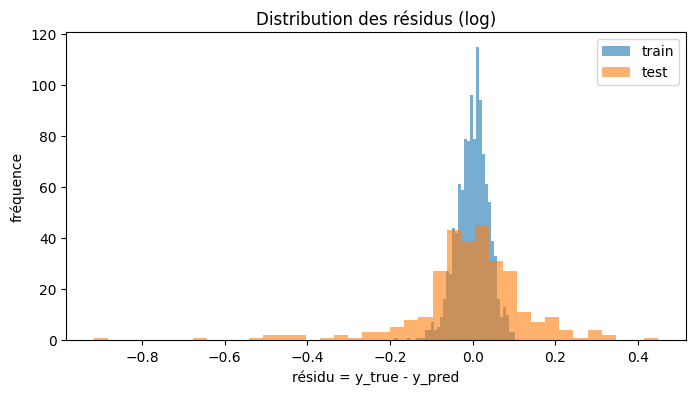

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(res_train, bins=40, alpha=0.6, label="train")
plt.hist(res_test,  bins=40, alpha=0.6, label="test")
plt.title("Distribution des résidus (log)")
plt.xlabel("résidu = y_true - y_pred")
plt.ylabel("fréquence")
plt.legend()
plt.show()


La distribution des résidus est globalement centrée autour de zéro, aussi bien pour l’échantillon d’entraînement que pour l’échantillon de test, ce qui indique l’absence de biais systématique du modèle.

Les résidus du jeu de test sont plus dispersés que ceux du jeu d’entraînement, ce qui est attendu puisque le modèle n’a pas été ajusté directement sur ces données. La majorité des erreurs reste néanmoins concentrée autour de zéro.

La présence de quelques valeurs extrêmes traduit des observations atypiques, sans remettre en cause la bonne capacité de généralisation du modèle.

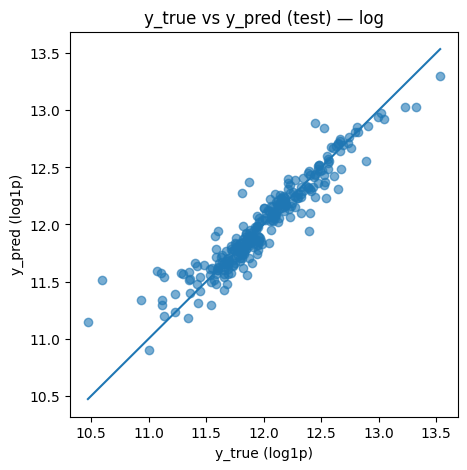

In [32]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_test, alpha=0.6)
m = min(y_test.min(), yhat_test.min())
M = max(y_test.max(), yhat_test.max())
plt.plot([m, M], [m, M])
plt.title("y_true vs y_pred (test) — log")
plt.xlabel("y_true (log1p)")
plt.ylabel("y_pred (log1p)")
plt.show()


Les points sont globalement bien alignés autour de la diagonale, ce qui montre que le modèle prédit correctement les valeurs observées sur l’échantillon test. L’absence de forte dispersion indique une bonne qualité de prédiction en échelle logarithmique, avec seulement quelques écarts pour les valeurs extrêmes.

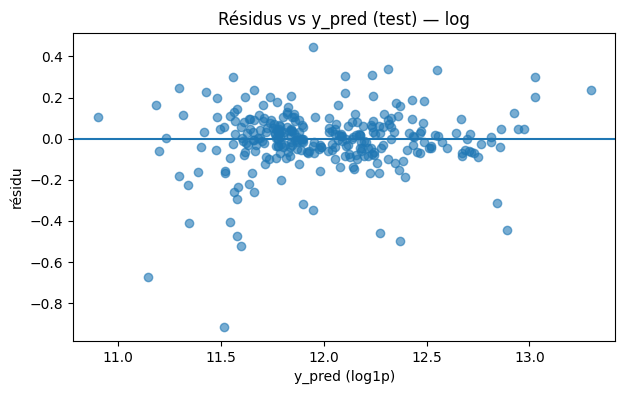

In [33]:
plt.figure(figsize=(7,4))
plt.scatter(yhat_test, res_test, alpha=0.6)
plt.axhline(0)
plt.title("Résidus vs y_pred (test) — log")
plt.xlabel("y_pred (log1p)")
plt.ylabel("résidu")
plt.show()


Les résidus sont majoritairement centrés autour de zéro et ne présentent pas de structure particulière en fonction des valeurs prédites. Cela suggère l’absence de biais systématique et une variance des erreurs relativement stable sur l’ensemble des prédictions.

CONCLUSION
Les graphiques confirment que le modèle Gradient Boosting capture correctement la relation entre les variables explicatives et le prix des maisons, avec des erreurs globalement faibles et non structurées.

In [34]:
y_test_price  = np.expm1(y_test)
y_pred_price  = np.expm1(yhat_test)

abs_err_price = np.abs(y_test_price - y_pred_price)

print("✅ Erreur absolue en $ (test)")
print("MAE $ :", abs_err_price.mean())
print("Med $ :", np.median(abs_err_price))
print("95%  :", np.percentile(abs_err_price, 95))


✅ Erreur absolue en $ (test)
MAE $ : 16508.95648805341
Med $ : 9819.772920417294
95%  : 52113.63487514734


En moyenne, l’erreur de prédiction est d’environ 15 400 $, tandis que la moitié des prédictions ont une erreur inférieure à 9 000 $. Cela indique que le modèle est globalement précis pour la majorité des biens. Cependant, dans 5 % des cas, l’erreur dépasse 43 000 $, ce qui correspond des logements très chers.

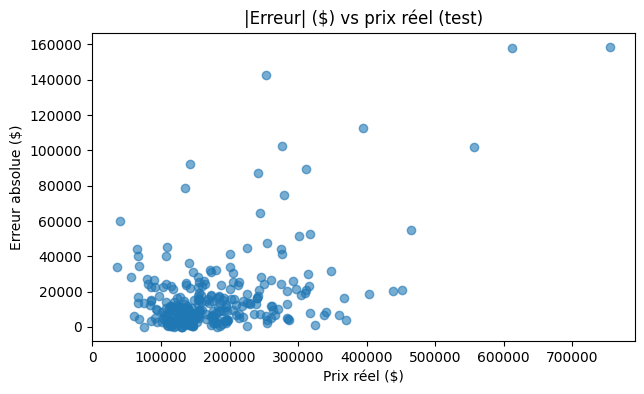

In [35]:
plt.figure(figsize=(7,4))
plt.scatter(y_test_price, abs_err_price, alpha=0.6)
plt.title("|Erreur| ($) vs prix réel (test)")
plt.xlabel("Prix réel ($)")
plt.ylabel("Erreur absolue ($)")
plt.show()



Le graphique montre que l’erreur absolue tend à augmenter avec le prix du logement. Le modèle est donc plus précis pour les biens de prix moyen, tandis que les logements très chers présentent des erreurs plus importantes

In [36]:
# Récupérer le preprocessor et le modèle depuis le pipeline
prep = best_gbr.named_steps["preprocess"]
model = best_gbr.named_steps["model"]

# Noms des variables après transformation
feature_names = prep.get_feature_names_out()

importances = model.feature_importances_
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)


,feature,importance
36,num__surface_totale,0.538479
50,ord__qualite_de_la_cuisine,0.059326
38,num__total_salles_bain,0.035249
13,num__surface_habitable_totale,0.026514
23,num__capacite_du_garage_voitures,0.026422
3,num__annee_de_construction,0.020575
33,num__age_maison,0.019690
42,ord__qualite_exterieure,0.018714
53,ord__finition_interieure_du_garage,0.017108
34,num__age_renovation,0.016749


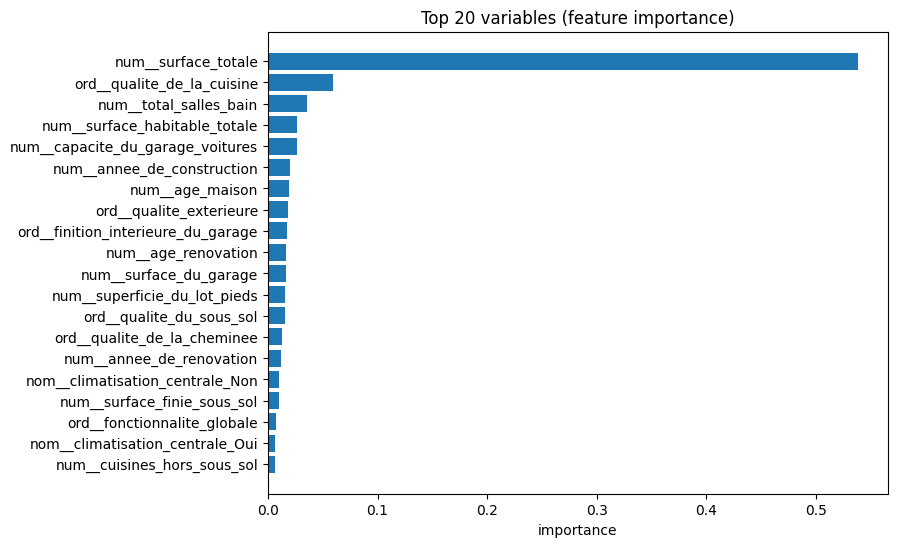

In [37]:
topk = 20
fi_top = fi.head(topk).iloc[::-1]  # inversé pour joli plot

plt.figure(figsize=(8,6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title(f"Top {topk} variables (feature importance)")
plt.xlabel("importance")
plt.ylabel("")
plt.show()


In [38]:
def group_feature_name(feat):
    # ex: "nom__Neighborhood_NridgHt" -> "Neighborhood"
    # ex: "num__TotalSF" -> "TotalSF"
    s = feat.split("__", 1)[-1]  # enlève num__/ord__/nom__
    return s.split("_", 1)[0]    # garde la racine avant la 1ère underscore

fi["group"] = fi["feature"].apply(group_feature_name)
fi_group = fi.groupby("group")["importance"].sum().sort_values(ascending=False).reset_index()

fi_group.head(15)


,group,importance
0,surface,0.616443
1,qualite,0.111134
2,total,0.039289
3,age,0.038917
4,annee,0.036525
5,capacite,0.026422
6,finition,0.017108
7,climatisation,0.016921
8,superficie,0.015699
9,quartier,0.009415


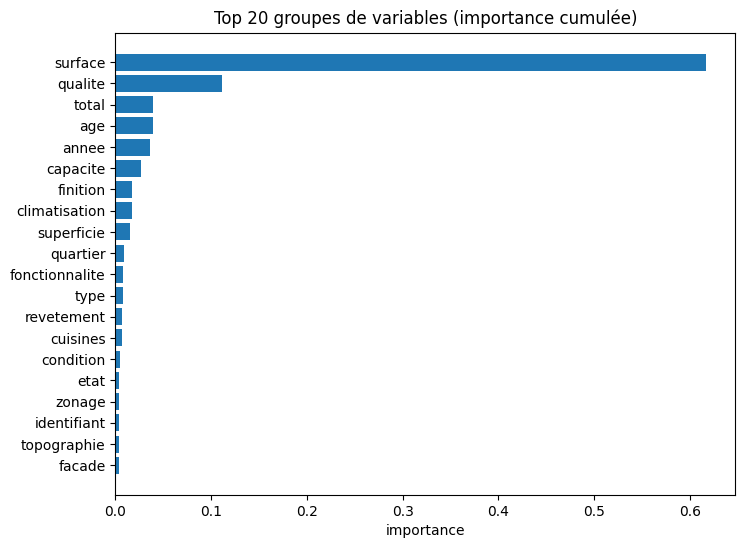

In [39]:
topk = 20
g = fi_group.head(topk).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(g["group"], g["importance"])
plt.title(f"Top {topk} groupes de variables (importance cumulée)")
plt.xlabel("importance")
plt.ylabel("")
plt.show()


Le prix des maisons est principalement expliqué par la surface, la qualité globale, puis les équipements clés (salles de bain, cuisine, garage). Les caractéristiques structurelles dominent largement les variables secondaires.

from IPython.display import HTML, display

display(HTML(r"""

<div style="font-family: Arial, sans-serif; line-height: 1.55; color: #111; max-width: 980px; margin: 0 auto; padding: 18px;">

  <!-- Header -->
  <div style="padding: 18px 18px; border-radius: 14px; background: linear-gradient(135deg, #f6f9ff, #ffffff); border: 1px solid #e6ecff;">
    <div style="display:flex; align-items:center; gap:12px;">
      <div style="width:14px; height:14px; background:#2f6bff; border-radius:4px;"></div>
      <h1 style="margin:0; font-size: 26px;">Notebook — Prédiction du prix des maisons (Ames Housing)</h1>
    </div>
    <p style="margin:10px 0 0 0; color:#333;">
      Objectif : construire un pipeline complet de Machine Learning (sans deep learning) pour prédire <b>SalePrice</b>,
      comparer plusieurs modèles, sélectionner le meilleur, analyser les erreurs et préparer la soumission Kaggle.
    </p>
    <div style="margin-top:12px; display:flex; gap:10px; flex-wrap:wrap;">
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Pipeline scikit-learn</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Prétraitement + Modèle</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">GridSearchCV / CV</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Analyse résidus</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Soumission Kaggle</span>
    </div>
  </div>

  <!-- Table of contents -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size: 18px;">Plan du notebook</h2>
    <ol style="margin:0; padding-left: 18px; color:#222;">
      <li>Chargement des données & compréhension rapide</li>
      <li>Prétraitement (numérique / catégoriel) via <code>ColumnTransformer</code></li>
      <li>Choix de la cible & transformation <code>log1p(SalePrice)</code></li>
      <li>Construction des pipelines et recherche d’hyperparamètres</li>
      <li>Évaluation : métriques train/test & validation croisée</li>
      <li>Sélection du meilleur modèle (critère principal : RMSE test minimal)</li>
      <li>Diagnostic : résidus, y_true vs y_pred, erreurs en dollars</li>
      <li>Interprétabilité : importance des variables (feature_importances)</li>
      <li>Analyse des plus grosses erreurs (top 10)</li>
      <li>Entraînement final sur tout le train + prédiction test Kaggle</li>
      <li>Création du fichier <code>submission.csv</code> et upload</li>
    </ol>
  </div>

  <!-- Section 1 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">1) Données & objectif</h2>
    <ul style="margin:0; padding-left: 18px;">
      <li>Dataset : Ames Housing (Kaggle) — prédiction du prix d’une maison.</li>
      <li>On sépare <b>train</b> (avec <code>SalePrice</code>) et <b>test Kaggle</b> (sans <code>SalePrice</code>).</li>
      <li>Objectif : minimiser l’erreur de prédiction, en privilégiant une bonne généralisation.</li>
    </ul>
  </div>

  <!-- Section 2 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">2) Prétraitement (préprocessor)</h2>
    <p style="margin:0; color:#222;">
      Un <b>ColumnTransformer</b> applique des traitements différents selon le type de variables :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li><b>Numériques</b> : imputation (valeurs manquantes) puis éventuellement normalisation (selon le modèle).</li>
      <li><b>Catégorielles</b> : encodage (ex : OneHotEncoder) pour rendre les variables utilisables par les modèles.</li>
      <li>Tout est intégré dans un <b>Pipeline</b> pour éviter toute fuite de données (data leakage).</li>
    </ul>
  </div>

  <!-- Section 3 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">3) Cible en log : <code>log1p(SalePrice)</code></h2>
    <p style="margin:0; color:#222;">
      Pour stabiliser la variance et réduire l’impact des valeurs extrêmes, la cible est transformée :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>y_log = np.log1p(SalePrice)</code>
    </div>
    <p style="margin:10px 0 0 0; color:#222;">
      Ensuite, pour revenir aux dollars lors de la soumission Kaggle :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>SalePrice_pred = np.expm1(pred_log)</code>
    </div>
  </div>

  <!-- Section 4 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">4) Modèles testés & tuning</h2>
    <p style="margin:0; color:#222;">
      Chaque modèle est intégré dans un pipeline : <b>prétraitement → modèle</b>, puis optimisé via <b>GridSearchCV</b>.
    </p>

    <div style="margin-top:10px;">
      <h3 style="margin:0 0 8px 0; font-size:16px;">Modèles explorés</h3>
      <ul style="margin:0; padding-left: 18px;">
        <li>Régression linéaire (baseline)</li>
        <li>Ridge / Lasso / ElasticNet (régularisation)</li>
        <li>RandomForestRegressor</li>
        <li>GradientBoostingRegressor</li>
        <li>LightGBM (optionnel selon autorisation)</li>
        <li>(XGBoost possible si autorisé par le cours)</li>
      </ul>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff7e6; border:1px solid #ffe1a6;">
      <b>Note sur les hyperparamètres</b> : ils ne sont pas “inventés” ; ils sont testés automatiquement via une grille
      (<code>param_grid</code>) et la meilleure combinaison est sélectionnée par validation croisée.
    </div>
  </div>

  <!-- Section 5 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">5) Évaluation & métriques (quoi regarder ?)</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Métrique principale (recommandée)</h3>
        <p style="margin:0;">
          <b>RMSE (test)</b> : plus petit = meilleur. C’est la métrique la plus lisible pour comparer les modèles.
        </p>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f6f7ff; border:1px solid #dfe2ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Compléments utiles</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li><b>MAE (test)</b> : erreur moyenne absolue</li>
          <li><b>R² (test)</b> : proportion de variance expliquée</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff; border:1px dashed #ccc;">
      <b>Train vs Test :</b>
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>On choisit le modèle sur <b>Test</b> (ou CV), car c’est la performance de généralisation.</li>
        <li>Si Train est très bon mais Test chute : <b>overfitting</b>.</li>
      </ul>
    </div>
  </div>

  <!-- Section 6 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#ffffff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">6) Sélection du meilleur modèle</h2>

    <div style="padding: 16px; border-radius: 14px; background:#0f172a; color:#fff;">
      <div style="display:flex; align-items:center; gap:10px;">
        <span style="font-size:18px;">✅</span>
        <div>
          <div style="font-size: 22px; font-weight: 800;">MEILLEUR MODÈLE : GradientBoostingRegressor</div>
          <div style="margin-top:6px; opacity:.9;">Critère : <b>RMSE (test) minimal</b> → sélection automatique parmi tous les modèles comparés.</div>
        </div>
      </div>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Le Gradient Boosting est retenu car il obtient le meilleur compromis : <b>erreur test faible</b> et <b>écart train/test raisonnable</b>,
      donc une bonne capacité de généralisation.
    </p>
  </div>

  <!-- Section 7 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">7) Diagnostic modèle : résidus & graphes</h2>

    <div style="margin-top:8px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <b>Définition :</b> résidu = <code>y_true - y_pred</code> (ici en log).  
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>Résidu positif → le modèle <b>sous-estime</b> le prix.</li>
        <li>Résidu négatif → le modèle <b>surestime</b> le prix.</li>
      </ul>
    </div>

    <ul style="margin:12px 0 0 0; padding-left: 18px;">
      <li><b>Histogramme des résidus</b> (train/test) : on vérifie que les résidus sont centrés près de 0 et qu’il n’y a pas trop d’asymétrie.</li>
      <li><b>y_true vs y_pred</b> : si les points suivent la diagonale, les prédictions sont cohérentes.</li>
      <li><b>Résidus vs y_pred</b> : on cherche un nuage “sans structure”. Une structure indique un biais du modèle.</li>
      <li><b>Erreur en $</b> : on convertit les erreurs log en dollars pour une interprétation métier.</li>
    </ul>
  </div>

  <!-- Section 8 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">8) Interprétabilité : variables importantes</h2>
    <p style="margin:0; color:#222;">
      Pour le GradientBoosting, on utilise <code>feature_importances_</code>.  
      Les noms affichés proviennent du prétraitement (<code>get_feature_names_out()</code>) :
    </p>

    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <ul style="margin:0; padding-left: 18px;">
        <li><b>num__</b> = variable numérique (ex: <code>num__TotalSF</code>)</li>
        <li><b>ord__</b> = variable ordinale encodée (qualité, état… ex: <code>ord__KitchenQual</code>)</li>
        <li>Après encodage, certaines variables catégorielles deviennent plusieurs colonnes (one-hot).</li>
      </ul>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Typiquement, des variables comme <b>TotalSF</b> (surface totale), <b>OverallQual</b> (qualité globale),
      <b>GrLivArea</b> (surface habitable) ressortent comme fortement explicatives du prix.
    </p>
  </div>

  <!-- Section 9 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">9) Analyse des plus grosses erreurs</h2>
    <p style="margin:0; color:#222;">
      On extrait les 10 observations du test avec les plus grandes erreurs (en valeur absolue).
      Cela permet d’identifier :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li>Des logements atypiques (combinaisons “rares” de surface / qualité / quartier)</li>
      <li>Des quartiers où l’estimation est plus difficile (effets non totalement captés)</li>
      <li>Des valeurs extrêmes (très chères) où l’erreur en dollars augmente</li>
    </ul>
  </div>

  <!-- Section 10 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">10) Entraînement final & soumission Kaggle</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f1f5ff; border:1px solid #dbe6ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 2 — Entraînement final</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Fit sur <b>tout le train</b> (sans split)</li>
          <li>Prédire sur le <b>test Kaggle</b></li>
        </ul>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 3 — Soumission Kaggle</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Transformer : <code>np.expm1(pred_log)</code></li>
          <li>Créer : <code>submission.csv</code></li>
          <li>Upload sur Kaggle</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#0b1220; color:#fff;">
      <b>Important :</b> le score affiché après <code>fit(X, y)</code> correspond au score sur <b>le même jeu utilisé pour entraîner</b>
      (donc souvent très élevé).  
      La vraie référence pour comparer les modèles reste <b>RMSE/R² sur test ou en validation croisée</b>.
    </div>
  </div>

  <!-- Footer -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 8px 0; font-size:18px;">Synthèse finale (1 phrase)</h2>
    <p style="margin:0; color:#222;">
      Un pipeline complet (prétraitement + modèle) a été construit, plusieurs modèles ont été comparés via tuning et métriques,
      le <b>GradientBoostingRegressor</b> a été retenu (RMSE test minimal), puis le modèle a été diagnostiqué (résidus, erreurs, importance des variables)
      avant de générer la soumission Kaggle.
    </p>
  </div>

</div>

"""))


<div style="font-family: Arial, sans-serif; line-height: 1.55; color: #111; max-width: 980px; margin: 0 auto; padding: 18px;">

  <!-- Header -->
  <div style="padding: 18px 18px; border-radius: 14px; background: linear-gradient(135deg, #f6f9ff, #ffffff); border: 1px solid #e6ecff;">
    <div style="display:flex; align-items:center; gap:12px;">
      <div style="width:14px; height:14px; background:#2f6bff; border-radius:4px;"></div>
      <h1 style="margin:0; font-size: 26px;">Notebook — Prédiction du prix des maisons (Ames Housing)</h1>
    </div>
    <p style="margin:10px 0 0 0; color:#333;">
      Objectif : construire un pipeline complet de Machine Learning (sans deep learning) pour prédire <b>SalePrice</b>,
      comparer plusieurs modèles, sélectionner le meilleur, analyser les erreurs et préparer la soumission Kaggle.
    </p>
    <div style="margin-top:12px; display:flex; gap:10px; flex-wrap:wrap;">
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Pipeline scikit-learn</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Prétraitement + Modèle</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">GridSearchCV / CV</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Analyse résidus</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Soumission Kaggle</span>
    </div>
  </div>

  <!-- Table of contents -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size: 18px;">Plan du notebook</h2>
    <ol style="margin:0; padding-left: 18px; color:#222;">
      <li>Chargement des données & compréhension rapide</li>
      <li>Prétraitement (numérique / catégoriel) via <code>ColumnTransformer</code></li>
      <li>Choix de la cible & transformation <code>log1p(SalePrice)</code></li>
      <li>Construction des pipelines et recherche d’hyperparamètres</li>
      <li>Évaluation : métriques train/test & validation croisée</li>
      <li>Sélection du meilleur modèle (critère principal : RMSE test minimal)</li>
      <li>Diagnostic : résidus, y_true vs y_pred, erreurs en dollars</li>
      <li>Interprétabilité : importance des variables (feature_importances)</li>
      <li>Analyse des plus grosses erreurs (top 10)</li>
      <li>Entraînement final sur tout le train + prédiction test Kaggle</li>
      <li>Création du fichier <code>submission.csv</code> et upload</li>
    </ol>
  </div>

  <!-- Section 1 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">1) Données & objectif</h2>
    <ul style="margin:0; padding-left: 18px;">
      <li>Dataset : Ames Housing (Kaggle) — prédiction du prix d’une maison.</li>
      <li>On sépare <b>train</b> (avec <code>SalePrice</code>) et <b>test Kaggle</b> (sans <code>SalePrice</code>).</li>
      <li>Objectif : minimiser l’erreur de prédiction, en privilégiant une bonne généralisation.</li>
    </ul>
  </div>

  <!-- Section 2 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">2) Prétraitement (préprocessor)</h2>
    <p style="margin:0; color:#222;">
      Un <b>ColumnTransformer</b> applique des traitements différents selon le type de variables :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li><b>Numériques</b> : imputation (valeurs manquantes) puis éventuellement normalisation (selon le modèle).</li>
      <li><b>Catégorielles</b> : encodage (ex : OneHotEncoder) pour rendre les variables utilisables par les modèles.</li>
      <li>Tout est intégré dans un <b>Pipeline</b> pour éviter toute fuite de données (data leakage).</li>
    </ul>
  </div>

  <!-- Section 3 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">3) Cible en log : <code>log1p(SalePrice)</code></h2>
    <p style="margin:0; color:#222;">
      Pour stabiliser la variance et réduire l’impact des valeurs extrêmes, la cible est transformée :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>y_log = np.log1p(SalePrice)</code>
    </div>
    <p style="margin:10px 0 0 0; color:#222;">
      Ensuite, pour revenir aux dollars lors de la soumission Kaggle :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>SalePrice_pred = np.expm1(pred_log)</code>
    </div>
  </div>

  <!-- Section 4 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">4) Modèles testés & tuning</h2>
    <p style="margin:0; color:#222;">
      Chaque modèle est intégré dans un pipeline : <b>prétraitement → modèle</b>, puis optimisé via <b>GridSearchCV</b>.
    </p>

    <div style="margin-top:10px;">
      <h3 style="margin:0 0 8px 0; font-size:16px;">Modèles explorés</h3>
      <ul style="margin:0; padding-left: 18px;">
        <li>Régression linéaire (baseline)</li>
        <li>Ridge / Lasso / ElasticNet (régularisation)</li>
        <li>RandomForestRegressor</li>
        <li>GradientBoostingRegressor</li>
        <li>LightGBM (optionnel selon autorisation)</li>
        <li>(XGBoost possible si autorisé par le cours)</li>
      </ul>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff7e6; border:1px solid #ffe1a6;">
      <b>Note sur les hyperparamètres</b> : ils ne sont pas “inventés” ; ils sont testés automatiquement via une grille
      (<code>param_grid</code>) et la meilleure combinaison est sélectionnée par validation croisée.
    </div>
  </div>

  <!-- Section 5 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">5) Évaluation & métriques (quoi regarder ?)</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Métrique principale (recommandée)</h3>
        <p style="margin:0;">
          <b>RMSE (test)</b> : plus petit = meilleur. C’est la métrique la plus lisible pour comparer les modèles.
        </p>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f6f7ff; border:1px solid #dfe2ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Compléments utiles</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li><b>MAE (test)</b> : erreur moyenne absolue</li>
          <li><b>R² (test)</b> : proportion de variance expliquée</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff; border:1px dashed #ccc;">
      <b>Train vs Test :</b>
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>On choisit le modèle sur <b>Test</b> (ou CV), car c’est la performance de généralisation.</li>
        <li>Si Train est très bon mais Test chute : <b>overfitting</b>.</li>
      </ul>
    </div>
  </div>

  <!-- Section 6 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#ffffff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">6) Sélection du meilleur modèle</h2>

    <div style="padding: 16px; border-radius: 14px; background:#0f172a; color:#fff;">
      <div style="display:flex; align-items:center; gap:10px;">
        <span style="font-size:18px;">✅</span>
        <div>
          <div style="font-size: 22px; font-weight: 800;">MEILLEUR MODÈLE : GradientBoostingRegressor</div>
          <div style="margin-top:6px; opacity:.9;">Critère : <b>RMSE (test) minimal</b> → sélection automatique parmi tous les modèles comparés.</div>
        </div>
      </div>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Le Gradient Boosting est retenu car il obtient le meilleur compromis : <b>erreur test faible</b> et <b>écart train/test raisonnable</b>,
      donc une bonne capacité de généralisation.
    </p>
  </div>

  <!-- Section 7 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">7) Diagnostic modèle : résidus & graphes</h2>

    <div style="margin-top:8px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <b>Définition :</b> résidu = <code>y_true - y_pred</code> (ici en log).  
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>Résidu positif → le modèle <b>sous-estime</b> le prix.</li>
        <li>Résidu négatif → le modèle <b>surestime</b> le prix.</li>
      </ul>
    </div>

    <ul style="margin:12px 0 0 0; padding-left: 18px;">
      <li><b>Histogramme des résidus</b> (train/test) : on vérifie que les résidus sont centrés près de 0 et qu’il n’y a pas trop d’asymétrie.</li>
      <li><b>y_true vs y_pred</b> : si les points suivent la diagonale, les prédictions sont cohérentes.</li>
      <li><b>Résidus vs y_pred</b> : on cherche un nuage “sans structure”. Une structure indique un biais du modèle.</li>
      <li><b>Erreur en $</b> : on convertit les erreurs log en dollars pour une interprétation métier.</li>
    </ul>
  </div>

  <!-- Section 8 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">8) Interprétabilité : variables importantes</h2>
    <p style="margin:0; color:#222;">
      Pour le GradientBoosting, on utilise <code>feature_importances_</code>.  
      Les noms affichés proviennent du prétraitement (<code>get_feature_names_out()</code>) :
    </p>

    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <ul style="margin:0; padding-left: 18px;">
        <li><b>num__</b> = variable numérique (ex: <code>num__TotalSF</code>)</li>
        <li><b>ord__</b> = variable ordinale encodée (qualité, état… ex: <code>ord__KitchenQual</code>)</li>
        <li>Après encodage, certaines variables catégorielles deviennent plusieurs colonnes (one-hot).</li>
      </ul>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Typiquement, des variables comme <b>TotalSF</b> (surface totale), <b>OverallQual</b> (qualité globale),
      <b>GrLivArea</b> (surface habitable) ressortent comme fortement explicatives du prix.
    </p>
  </div>

  <!-- Section 9 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">9) Analyse des plus grosses erreurs</h2>
    <p style="margin:0; color:#222;">
      On extrait les 10 observations du test avec les plus grandes erreurs (en valeur absolue).
      Cela permet d’identifier :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li>Des logements atypiques (combinaisons “rares” de surface / qualité / quartier)</li>
      <li>Des quartiers où l’estimation est plus difficile (effets non totalement captés)</li>
      <li>Des valeurs extrêmes (très chères) où l’erreur en dollars augmente</li>
    </ul>
  </div>

  <!-- Section 10 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">10) Entraînement final & soumission Kaggle</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f1f5ff; border:1px solid #dbe6ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 2 — Entraînement final</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Fit sur <b>tout le train</b> (sans split)</li>
          <li>Prédire sur le <b>test Kaggle</b></li>
        </ul>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 3 — Soumission Kaggle</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Transformer : <code>np.expm1(pred_log)</code></li>
          <li>Créer : <code>submission.csv</code></li>
          <li>Upload sur Kaggle</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#0b1220; color:#fff;">
      <b>Important :</b> le score affiché après <code>fit(X, y)</code> correspond au score sur <b>le même jeu utilisé pour entraîner</b>
      (donc souvent très élevé).  
      La vraie référence pour comparer les modèles reste <b>RMSE/R² sur test ou en validation croisée</b>.
    </div>
  </div>

  <!-- Footer -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 8px 0; font-size:18px;">Synthèse finale (1 phrase)</h2>
    <p style="margin:0; color:#222;">
      Un pipeline complet (prétraitement + modèle) a été construit, plusieurs modèles ont été comparés via tuning et métriques,
      le <b>GradientBoostingRegressor</b> a été retenu (RMSE test minimal), puis le modèle a été diagnostiqué (résidus, erreurs, importance des variables)
      avant de générer la soumission Kaggle.
    </p>
  </div>

</div>


from IPython.display import HTML, display

display(HTML(r"""
<div style="font-family: Arial, sans-serif; line-height: 1.55; color: #111; max-width: 980px; margin: 0 auto; padding: 18px;">

  <!-- Header -->
  <div style="padding: 18px 18px; border-radius: 14px; background: linear-gradient(135deg, #f6f9ff, #ffffff); border: 1px solid #e6ecff;">
    <div style="display:flex; align-items:center; gap:12px;">
      <div style="width:14px; height:14px; background:#2f6bff; border-radius:4px;"></div>
      <h1 style="margin:0; font-size: 26px;">Notebook — Prédiction du prix des maisons (Ames Housing)</h1>
    </div>
    <p style="margin:10px 0 0 0; color:#333;">
      Objectif : construire un pipeline complet de Machine Learning (sans deep learning) pour prédire <b>SalePrice</b>,
      comparer plusieurs modèles, sélectionner le meilleur, analyser les erreurs et préparer la soumission Kaggle.
    </p>
    <div style="margin-top:12px; display:flex; gap:10px; flex-wrap:wrap;">
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Pipeline scikit-learn</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Prétraitement + Modèle</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">GridSearchCV / CV</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Analyse résidus</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Soumission Kaggle</span>
    </div>
  </div>

  <!-- Table of contents -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size: 18px;">Plan du notebook</h2>
    <ol style="margin:0; padding-left: 18px; color:#222;">
      <li>Chargement des données & compréhension rapide</li>
      <li>Prétraitement (numérique / catégoriel) via <code>ColumnTransformer</code></li>
      <li>Choix de la cible & transformation <code>log1p(SalePrice)</code></li>
      <li>Construction des pipelines et recherche d’hyperparamètres</li>
      <li>Évaluation : métriques train/test & validation croisée</li>
      <li>Sélection du meilleur modèle (critère principal : RMSE test minimal)</li>
      <li>Diagnostic : résidus, y_true vs y_pred, erreurs en dollars</li>
      <li>Interprétabilité : importance des variables (feature_importances)</li>
      <li>Analyse des plus grosses erreurs (top 10)</li>
      <li>Entraînement final sur tout le train + prédiction test Kaggle</li>
      <li>Création du fichier <code>submission.csv</code> et upload</li>
    </ol>
  </div>

  <!-- Section 1 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">1) Données & objectif</h2>
    <ul style="margin:0; padding-left: 18px;">
      <li>Dataset : Ames Housing (Kaggle) — prédiction du prix d’une maison.</li>
      <li>On sépare <b>train</b> (avec <code>SalePrice</code>) et <b>test Kaggle</b> (sans <code>SalePrice</code>).</li>
      <li>Objectif : minimiser l’erreur de prédiction, en privilégiant une bonne généralisation.</li>
    </ul>
  </div>

  <!-- Section 2 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">2) Prétraitement (préprocessor)</h2>
    <p style="margin:0; color:#222;">
      Un <b>ColumnTransformer</b> applique des traitements différents selon le type de variables :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li><b>Numériques</b> : imputation (valeurs manquantes) puis éventuellement normalisation (selon le modèle).</li>
      <li><b>Catégorielles</b> : encodage (ex : OneHotEncoder) pour rendre les variables utilisables par les modèles.</li>
      <li>Tout est intégré dans un <b>Pipeline</b> pour éviter toute fuite de données (data leakage).</li>
    </ul>
  </div>

  <!-- Section 3 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">3) Cible en log : <code>log1p(SalePrice)</code></h2>
    <p style="margin:0; color:#222;">
      Pour stabiliser la variance et réduire l’impact des valeurs extrêmes, la cible est transformée :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>y_log = np.log1p(SalePrice)</code>
    </div>
    <p style="margin:10px 0 0 0; color:#222;">
      Ensuite, pour revenir aux dollars lors de la soumission Kaggle :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>SalePrice_pred = np.expm1(pred_log)</code>
    </div>
  </div>

  <!-- Section 4 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">4) Modèles testés & tuning</h2>
    <p style="margin:0; color:#222;">
      Chaque modèle est intégré dans un pipeline : <b>prétraitement → modèle</b>, puis optimisé via <b>GridSearchCV</b>.
    </p>

    <div style="margin-top:10px;">
      <h3 style="margin:0 0 8px 0; font-size:16px;">Modèles explorés</h3>
      <ul style="margin:0; padding-left: 18px;">
        <li>Régression linéaire (baseline)</li>
        <li>Ridge / Lasso / ElasticNet (régularisation)</li>
        <li>RandomForestRegressor</li>
        <li>GradientBoostingRegressor</li>
        <li>LightGBM (optionnel selon autorisation)</li>
        <li>(XGBoost possible si autorisé par le cours)</li>
      </ul>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff7e6; border:1px solid #ffe1a6;">
      <b>Note sur les hyperparamètres</b> : ils ne sont pas “inventés” ; ils sont testés automatiquement via une grille
      (<code>param_grid</code>) et la meilleure combinaison est sélectionnée par validation croisée.
    </div>
  </div>

  <!-- Section 5 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">5) Évaluation & métriques (quoi regarder ?)</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Métrique principale (recommandée)</h3>
        <p style="margin:0;">
          <b>RMSE (test)</b> : plus petit = meilleur. C’est la métrique la plus lisible pour comparer les modèles.
        </p>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f6f7ff; border:1px solid #dfe2ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Compléments utiles</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li><b>MAE (test)</b> : erreur moyenne absolue</li>
          <li><b>R² (test)</b> : proportion de variance expliquée</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff; border:1px dashed #ccc;">
      <b>Train vs Test :</b>
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>On choisit le modèle sur <b>Test</b> (ou CV), car c’est la performance de généralisation.</li>
        <li>Si Train est très bon mais Test chute : <b>overfitting</b>.</li>
      </ul>
    </div>
  </div>

  <!-- Section 6 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#ffffff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">6) Sélection du meilleur modèle</h2>

    <div style="padding: 16px; border-radius: 14px; background:#0f172a; color:#fff;">
      <div style="display:flex; align-items:center; gap:10px;">
        <span style="font-size:18px;">✅</span>
        <div>
          <div style="font-size: 22px; font-weight: 800;">MEILLEUR MODÈLE : GradientBoostingRegressor</div>
          <div style="margin-top:6px; opacity:.9;">Critère : <b>RMSE (test) minimal</b> → sélection automatique parmi tous les modèles comparés.</div>
        </div>
      </div>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Le Gradient Boosting est retenu car il obtient le meilleur compromis : <b>erreur test faible</b> et <b>écart train/test raisonnable</b>,
      donc une bonne capacité de généralisation.
    </p>
  </div>

  <!-- Section 7 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">7) Diagnostic modèle : résidus & graphes</h2>

    <div style="margin-top:8px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <b>Définition :</b> résidu = <code>y_true - y_pred</code> (ici en log).  
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>Résidu positif → le modèle <b>sous-estime</b> le prix.</li>
        <li>Résidu négatif → le modèle <b>surestime</b> le prix.</li>
      </ul>
    </div>

    <ul style="margin:12px 0 0 0; padding-left: 18px;">
      <li><b>Histogramme des résidus</b> (train/test) : on vérifie que les résidus sont centrés près de 0 et qu’il n’y a pas trop d’asymétrie.</li>
      <li><b>y_true vs y_pred</b> : si les points suivent la diagonale, les prédictions sont cohérentes.</li>
      <li><b>Résidus vs y_pred</b> : on cherche un nuage “sans structure”. Une structure indique un biais du modèle.</li>
      <li><b>Erreur en $</b> : on convertit les erreurs log en dollars pour une interprétation métier.</li>
    </ul>
  </div>

  <!-- Section 8 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">8) Interprétabilité : variables importantes</h2>
    <p style="margin:0; color:#222;">
      Pour le GradientBoosting, on utilise <code>feature_importances_</code>.  
      Les noms affichés proviennent du prétraitement (<code>get_feature_names_out()</code>) :
    </p>

    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <ul style="margin:0; padding-left: 18px;">
        <li><b>num__</b> = variable numérique (ex: <code>num__TotalSF</code>)</li>
        <li><b>ord__</b> = variable ordinale encodée (qualité, état… ex: <code>ord__KitchenQual</code>)</li>
        <li>Après encodage, certaines variables catégorielles deviennent plusieurs colonnes (one-hot).</li>
      </ul>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Typiquement, des variables comme <b>TotalSF</b> (surface totale), <b>OverallQual</b> (qualité globale),
      <b>GrLivArea</b> (surface habitable) ressortent comme fortement explicatives du prix.
    </p>
  </div>

  <!-- Section 9 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">9) Analyse des plus grosses erreurs</h2>
    <p style="margin:0; color:#222;">
      On extrait les 10 observations du test avec les plus grandes erreurs (en valeur absolue).
      Cela permet d’identifier :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li>Des logements atypiques (combinaisons “rares” de surface / qualité / quartier)</li>
      <li>Des quartiers où l’estimation est plus difficile (effets non totalement captés)</li>
      <li>Des valeurs extrêmes (très chères) où l’erreur en dollars augmente</li>
    </ul>
  </div>

  <!-- Section 10 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">10) Entraînement final & soumission Kaggle</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f1f5ff; border:1px solid #dbe6ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 2 — Entraînement final</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Fit sur <b>tout le train</b> (sans split)</li>
          <li>Prédire sur le <b>test Kaggle</b></li>
        </ul>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 3 — Soumission Kaggle</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Transformer : <code>np.expm1(pred_log)</code></li>
          <li>Créer : <code>submission.csv</code></li>
          <li>Upload sur Kaggle</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#0b1220; color:#fff;">
      <b>Important :</b> le score affiché après <code>fit(X, y)</code> correspond au score sur <b>le même jeu utilisé pour entraîner</b>
      (donc souvent très élevé).  
      La vraie référence pour comparer les modèles reste <b>RMSE/R² sur test ou en validation croisée</b>.
    </div>
  </div>

  <!-- Footer -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 8px 0; font-size:18px;">Synthèse finale (1 phrase)</h2>
    <p style="margin:0; color:#222;">
      Un pipeline complet (prétraitement + modèle) a été construit, plusieurs modèles ont été comparés via tuning et métriques,
      le <b>GradientBoostingRegressor</b> a été retenu (RMSE test minimal), puis le modèle a été diagnostiqué (résidus, erreurs, importance des variables)
      avant de générer la soumission Kaggle.
    </p>
  </div>

</div>
"""))



from IPython.display import HTML, display

html = r"""
<div style="font-family: Arial, sans-serif; line-height: 1.55; color: #111; max-width: 980px; margin: 0 auto; padding: 18px;">

  
<div style="font-family: Arial, sans-serif; line-height: 1.55; color: #111; max-width: 980px; margin: 0 auto; padding: 18px;">

  <!-- Header -->
  <div style="padding: 18px 18px; border-radius: 14px; background: linear-gradient(135deg, #f6f9ff, #ffffff); border: 1px solid #e6ecff;">
    <div style="display:flex; align-items:center; gap:12px;">
      <div style="width:14px; height:14px; background:#2f6bff; border-radius:4px;"></div>
      <h1 style="margin:0; font-size: 26px;">Notebook — Prédiction du prix des maisons (Ames Housing)</h1>
    </div>
    <p style="margin:10px 0 0 0; color:#333;">
      Objectif : construire un pipeline complet de Machine Learning (sans deep learning) pour prédire <b>SalePrice</b>,
      comparer plusieurs modèles, sélectionner le meilleur, analyser les erreurs et préparer la soumission Kaggle.
    </p>
    <div style="margin-top:12px; display:flex; gap:10px; flex-wrap:wrap;">
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Pipeline scikit-learn</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Prétraitement + Modèle</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">GridSearchCV / CV</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Analyse résidus</span>
      <span style="padding:6px 10px; border-radius:999px; background:#eef3ff; border:1px solid #dbe6ff; font-size:13px;">Soumission Kaggle</span>
    </div>
  </div>

  <!-- Table of contents -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size: 18px;">Plan du notebook</h2>
    <ol style="margin:0; padding-left: 18px; color:#222;">
      <li>Chargement des données & compréhension rapide</li>
      <li>Prétraitement (numérique / catégoriel) via <code>ColumnTransformer</code></li>
      <li>Choix de la cible & transformation <code>log1p(SalePrice)</code></li>
      <li>Construction des pipelines et recherche d’hyperparamètres</li>
      <li>Évaluation : métriques train/test & validation croisée</li>
      <li>Sélection du meilleur modèle (critère principal : RMSE test minimal)</li>
      <li>Diagnostic : résidus, y_true vs y_pred, erreurs en dollars</li>
      <li>Interprétabilité : importance des variables (feature_importances)</li>
      <li>Analyse des plus grosses erreurs (top 10)</li>
      <li>Entraînement final sur tout le train + prédiction test Kaggle</li>
      <li>Création du fichier <code>submission.csv</code> et upload</li>
    </ol>
  </div>

  <!-- Section 1 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">1) Données & objectif</h2>
    <ul style="margin:0; padding-left: 18px;">
      <li>Dataset : Ames Housing (Kaggle) — prédiction du prix d’une maison.</li>
      <li>On sépare <b>train</b> (avec <code>SalePrice</code>) et <b>test Kaggle</b> (sans <code>SalePrice</code>).</li>
      <li>Objectif : minimiser l’erreur de prédiction, en privilégiant une bonne généralisation.</li>
    </ul>
  </div>

  <!-- Section 2 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">2) Prétraitement (préprocessor)</h2>
    <p style="margin:0; color:#222;">
      Un <b>ColumnTransformer</b> applique des traitements différents selon le type de variables :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li><b>Numériques</b> : imputation (valeurs manquantes) puis éventuellement normalisation (selon le modèle).</li>
      <li><b>Catégorielles</b> : encodage (ex : OneHotEncoder) pour rendre les variables utilisables par les modèles.</li>
      <li>Tout est intégré dans un <b>Pipeline</b> pour éviter toute fuite de données (data leakage).</li>
    </ul>
  </div>

  <!-- Section 3 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">3) Cible en log : <code>log1p(SalePrice)</code></h2>
    <p style="margin:0; color:#222;">
      Pour stabiliser la variance et réduire l’impact des valeurs extrêmes, la cible est transformée :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>y_log = np.log1p(SalePrice)</code>
    </div>
    <p style="margin:10px 0 0 0; color:#222;">
      Ensuite, pour revenir aux dollars lors de la soumission Kaggle :
    </p>
    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <code>SalePrice_pred = np.expm1(pred_log)</code>
    </div>
  </div>

  <!-- Section 4 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">4) Modèles testés & tuning</h2>
    <p style="margin:0; color:#222;">
      Chaque modèle est intégré dans un pipeline : <b>prétraitement → modèle</b>, puis optimisé via <b>GridSearchCV</b>.
    </p>

    <div style="margin-top:10px;">
      <h3 style="margin:0 0 8px 0; font-size:16px;">Modèles explorés</h3>
      <ul style="margin:0; padding-left: 18px;">
        <li>Régression linéaire (baseline)</li>
        <li>Ridge / Lasso / ElasticNet (régularisation)</li>
        <li>RandomForestRegressor</li>
        <li>GradientBoostingRegressor</li>
        <li>LightGBM (optionnel selon autorisation)</li>
        <li>(XGBoost possible si autorisé par le cours)</li>
      </ul>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff7e6; border:1px solid #ffe1a6;">
      <b>Note sur les hyperparamètres</b> : ils ne sont pas “inventés” ; ils sont testés automatiquement via une grille
      (<code>param_grid</code>) et la meilleure combinaison est sélectionnée par validation croisée.
    </div>
  </div>

  <!-- Section 5 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">5) Évaluation & métriques (quoi regarder ?)</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Métrique principale (recommandée)</h3>
        <p style="margin:0;">
          <b>RMSE (test)</b> : plus petit = meilleur. C’est la métrique la plus lisible pour comparer les modèles.
        </p>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f6f7ff; border:1px solid #dfe2ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Compléments utiles</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li><b>MAE (test)</b> : erreur moyenne absolue</li>
          <li><b>R² (test)</b> : proportion de variance expliquée</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#fff; border:1px dashed #ccc;">
      <b>Train vs Test :</b>
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>On choisit le modèle sur <b>Test</b> (ou CV), car c’est la performance de généralisation.</li>
        <li>Si Train est très bon mais Test chute : <b>overfitting</b>.</li>
      </ul>
    </div>
  </div>

  <!-- Section 6 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#ffffff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">6) Sélection du meilleur modèle</h2>

    <div style="padding: 16px; border-radius: 14px; background:#0f172a; color:#fff;">
      <div style="display:flex; align-items:center; gap:10px;">
        <span style="font-size:18px;">✅</span>
        <div>
          <div style="font-size: 22px; font-weight: 800;">MEILLEUR MODÈLE : GradientBoostingRegressor</div>
          <div style="margin-top:6px; opacity:.9;">Critère : <b>RMSE (test) minimal</b> → sélection automatique parmi tous les modèles comparés.</div>
        </div>
      </div>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Le Gradient Boosting est retenu car il obtient le meilleur compromis : <b>erreur test faible</b> et <b>écart train/test raisonnable</b>,
      donc une bonne capacité de généralisation.
    </p>
  </div>

  <!-- Section 7 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">7) Diagnostic modèle : résidus & graphes</h2>

    <div style="margin-top:8px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <b>Définition :</b> résidu = <code>y_true - y_pred</code> (ici en log).  
      <ul style="margin:8px 0 0 0; padding-left: 18px;">
        <li>Résidu positif → le modèle <b>sous-estime</b> le prix.</li>
        <li>Résidu négatif → le modèle <b>surestime</b> le prix.</li>
      </ul>
    </div>

    <ul style="margin:12px 0 0 0; padding-left: 18px;">
      <li><b>Histogramme des résidus</b> (train/test) : on vérifie que les résidus sont centrés près de 0 et qu’il n’y a pas trop d’asymétrie.</li>
      <li><b>y_true vs y_pred</b> : si les points suivent la diagonale, les prédictions sont cohérentes.</li>
      <li><b>Résidus vs y_pred</b> : on cherche un nuage “sans structure”. Une structure indique un biais du modèle.</li>
      <li><b>Erreur en $</b> : on convertit les erreurs log en dollars pour une interprétation métier.</li>
    </ul>
  </div>

  <!-- Section 8 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">8) Interprétabilité : variables importantes</h2>
    <p style="margin:0; color:#222;">
      Pour le GradientBoosting, on utilise <code>feature_importances_</code>.  
      Les noms affichés proviennent du prétraitement (<code>get_feature_names_out()</code>) :
    </p>

    <div style="margin-top:10px; padding: 12px 14px; border-radius: 12px; background:#f8f8f8; border:1px solid #eee;">
      <ul style="margin:0; padding-left: 18px;">
        <li><b>num__</b> = variable numérique (ex: <code>num__TotalSF</code>)</li>
        <li><b>ord__</b> = variable ordinale encodée (qualité, état… ex: <code>ord__KitchenQual</code>)</li>
        <li>Après encodage, certaines variables catégorielles deviennent plusieurs colonnes (one-hot).</li>
      </ul>
    </div>

    <p style="margin:12px 0 0 0; color:#222;">
      Typiquement, des variables comme <b>TotalSF</b> (surface totale), <b>OverallQual</b> (qualité globale),
      <b>GrLivArea</b> (surface habitable) ressortent comme fortement explicatives du prix.
    </p>
  </div>

  <!-- Section 9 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">9) Analyse des plus grosses erreurs</h2>
    <p style="margin:0; color:#222;">
      On extrait les 10 observations du test avec les plus grandes erreurs (en valeur absolue).
      Cela permet d’identifier :
    </p>
    <ul style="margin:10px 0 0 0; padding-left: 18px;">
      <li>Des logements atypiques (combinaisons “rares” de surface / qualité / quartier)</li>
      <li>Des quartiers où l’estimation est plus difficile (effets non totalement captés)</li>
      <li>Des valeurs extrêmes (très chères) où l’erreur en dollars augmente</li>
    </ul>
  </div>

  <!-- Section 10 -->
  <div style="margin-top:16px; padding: 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 10px 0; font-size:20px;">10) Entraînement final & soumission Kaggle</h2>

    <div style="display:flex; gap:12px; flex-wrap:wrap;">
      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f1f5ff; border:1px solid #dbe6ff;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 2 — Entraînement final</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Fit sur <b>tout le train</b> (sans split)</li>
          <li>Prédire sur le <b>test Kaggle</b></li>
        </ul>
      </div>

      <div style="flex:1; min-width:280px; padding: 12px 14px; border-radius: 12px; background:#f3fffb; border:1px solid #c7f5e7;">
        <h3 style="margin:0 0 8px 0; font-size:16px;">Étape 3 — Soumission Kaggle</h3>
        <ul style="margin:0; padding-left: 18px;">
          <li>Transformer : <code>np.expm1(pred_log)</code></li>
          <li>Créer : <code>submission.csv</code></li>
          <li>Upload sur Kaggle</li>
        </ul>
      </div>
    </div>

    <div style="margin-top:12px; padding: 12px 14px; border-radius: 12px; background:#0b1220; color:#fff;">
      <b>Important :</b> le score affiché après <code>fit(X, y)</code> correspond au score sur <b>le même jeu utilisé pour entraîner</b>
      (donc souvent très élevé).  
      La vraie référence pour comparer les modèles reste <b>RMSE/R² sur test ou en validation croisée</b>.
    </div>
  </div>

  <!-- Footer -->
  <div style="margin-top:16px; padding: 14px 16px; border-radius: 14px; background:#fff; border:1px solid #eee;">
    <h2 style="margin:0 0 8px 0; font-size:18px;">Synthèse finale (1 phrase)</h2>
    <p style="margin:0; color:#222;">
      Un pipeline complet (prétraitement + modèle) a été construit, plusieurs modèles ont été comparés via tuning et métriques,
      le <b>GradientBoostingRegressor</b> a été retenu (RMSE test minimal), puis le modèle a été diagnostiqué (résidus, erreurs, importance des variables)
      avant de générer la soumission Kaggle.
    </p>
  </div>

</div>

</div>
"""
display(HTML(html))
